## Critical Analysis of Machine Learning and Deep Learning Models for Predicting Medical Equipment Demand in Hospitals

Dataset : https://data.cms.gov/provider-summary-by-type-of-service/medicare-durable-medical-equipment-devices-supplies/medicare-durable-medical-equipment-devices-supplies-by-geography-and-service

### ANALYSIS 1 (2014-2022):

In [1]:
#libraries
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import joblib
from statsmodels.tsa.statespace.sarimax import SARIMAX
import shap
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [5]:
#Data directories
DATA_DIR = "."
OUTPUT_DIR = "./processed"

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"Created directory: {OUTPUT_DIR}")
else:
    print(f"Output directory already exists: {OUTPUT_DIR}")
def year_from_fname(path):
    """
    Extracts a year (20YY) from filenames like 'dy14_geor.csv'- 2014
    """
    filename = os.path.basename(path)
    match = re.search(r"dy(\d{2})", filename)
    if not match:
        raise ValueError(f"Could not find year in filename: {path}")
    yy = int(match.group(1))
    year = 2000 + yy
    return year

#CSV files with matching name pattern
pattern = os.path.join(DATA_DIR, "mup_dme_ry24_p05_v10_dy*_geor.csv")
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError("No matching CSV files found. Please check your folder path or filenames.")
print(f"Found {len(files)} files.")
print("First few files:")
for f in files[:3]:
    print("  -", f)

Output directory already exists: ./processed
Found 9 files.
First few files:
  - .\mup_dme_ry24_p05_v10_dy14_geor.csv
  - .\mup_dme_ry24_p05_v10_dy15_geor.csv
  - .\mup_dme_ry24_p05_v10_dy16_geor.csv


### DATA PROCESSING

In [4]:
# Step 1.1 — Merging and cleaning of the dataset 
frames = []

#Reading all the files and adding a year column
for f in files:
    year = year_from_fname(f)
    print(f"Reading file: {f} (Year: {year})")
    
    df = pd.read_csv(f)
    df["Year"] = year
    frames.append(df)

#Merging
combined = pd.concat(frames, ignore_index=True)
print("Merged DataFrame shape:", combined.shape)

Reading file: .\mup_dme_ry24_p05_v10_dy14_geor.csv (Year: 2014)
Reading file: .\mup_dme_ry24_p05_v10_dy15_geor.csv (Year: 2015)
Reading file: .\mup_dme_ry24_p05_v10_dy16_geor.csv (Year: 2016)
Reading file: .\mup_dme_ry24_p05_v10_dy17_geor.csv (Year: 2017)
Reading file: .\mup_dme_ry24_p05_v10_dy18_geor.csv (Year: 2018)
Reading file: .\mup_dme_ry24_p05_v10_dy19_geor.csv (Year: 2019)
Reading file: .\mup_dme_ry24_p05_v10_dy20_geor.csv (Year: 2020)
Reading file: .\mup_dme_ry24_p05_v10_dy21_geor.csv (Year: 2021)
Reading file: .\mup_dme_ry24_p05_v10_dy22_geor.csv (Year: 2022)
Merged DataFrame shape: (374574, 19)


In [4]:
#Data Preview Before Cleaning
print("Preview of merged raw dataset (first 10 rows):")
combined.head(10)

Preview of merged raw dataset (first 10 rows):


,Rfrg_Prvdr_Geo_Lvl,Rfrg_Prvdr_Geo_Cd,Rfrg_Prvdr_Geo_Desc,RBCS_Lvl,RBCS_Id,RBCS_Desc,HCPCS_Cd,HCPCS_Desc,Suplr_Rentl_Ind,Tot_Rfrg_Prvdrs,Tot_Suplrs,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt,Year
0,National,NaN,National,Drugs Administered Through DME,DG000N,DME-Drugs Administered Through DME,J1817,"Insulin for administration through dme (i.e., ...",N,6830,8928,12351.0,54724,5258684,10.762325,2.783783,2.131986,2.131986,2014
1,State,01,Alabama,Drugs Administered Through DME,DG000N,DME-Drugs Administered Through DME,J1817,"Insulin for administration through dme (i.e., ...",N,128,222,305.0,1332,138847,10.252058,2.796111,2.067193,2.067193,2014
2,State,02,Alaska,Drugs Administered Through DME,DG000N,DME-Drugs Administered Through DME,J1817,"Insulin for administration through dme (i.e., ...",N,8,8,NaN,27,2160,10.691454,2.800000,2.164935,2.164935,2014
3,State,04,Arizona,Drugs Administered Through DME,DG000N,DME-Drugs Administered Through DME,J1817,"Insulin for administration through dme (i.e., ...",N,168,246,293.0,1151,106080,10.870120,2.800000,2.165747,2.165747,2014
4,State,05,Arkansas,Drugs Administered Through DME,DG000N,DME-Drugs Administered Through DME,J1817,"Insulin for administration through dme (i.e., ...",N,85,107,177.0,843,77090,10.457401,2.791503,2.160118,2.160118,2014
5,State,06,California,Drugs Administered Through DME,DG000N,DME-Drugs Administered Through DME,J1817,"Insulin for administration through dme (i.e., ...",N,352,447,504.0,2246,184666,10.797624,2.799330,2.152167,2.152167,2014
6,State,08,Colorado,Drugs Administered Through DME,DG000N,DME-Drugs Administered Through DME,J1817,"Insulin for administration through dme (i.e., ...",N,100,145,163.0,749,61110,10.783493,2.800000,2.143816,2.143816,2014
7,State,09,Connecticut,Drugs Administered Through DME,DG000N,DME-Drugs Administered Through DME,J1817,"Insulin for administration through dme (i.e., ...",N,59,91,97.0,355,45340,9.737425,2.346096,1.820303,1.820303,2014
8,State,10,Delaware,Drugs Administered Through DME,DG000N,DME-Drugs Administered Through DME,J1817,"Insulin for administration through dme (i.e., ...",N,23,33,43.0,156,15360,12.134184,2.800000,2.156796,2.156796,2014
9,State,11,District of Columbia,Drugs Administered Through DME,DG000N,DME-Drugs Administered Through DME,J1817,"Insulin for administration through dme (i.e., ...",N,5,7,NaN,19,1540,10.987253,2.800000,2.195234,2.195234,2014


In [5]:
# Drop 'National' rows to keep data in the state-level
if "Rfrg_Prvdr_Geo_Lvl" in combined.columns:
    before = combined.shape[0]
    combined = combined[combined["Rfrg_Prvdr_Geo_Lvl"].str.lower() != "national"].copy()
    after = combined.shape[0]
    print(f"Removed {before - after} 'National' rows.")

# Rename columns
combined = combined.rename(columns={
    "Rfrg_Prvdr_Geo_Lvl": "Geo_Level",
    "Rfrg_Prvdr_Geo_Cd": "State_Code",
    "Rfrg_Prvdr_Geo_Desc": "State"
})
print("Columns renamed successfully.")

Removed 15773 'National' rows.
Columns renamed successfully.


In [6]:
# Convert numeric columns to float for consistency
numeric_cols = [
    "State_Code",
    "Tot_Rfrg_Prvdrs",
    "Tot_Suplrs",
    "Tot_Suplr_Benes",
    "Tot_Suplr_Clms",
    "Tot_Suplr_Srvcs",
    "Avg_Suplr_Sbmtd_Chrg",
    "Avg_Suplr_Mdcr_Alowd_Amt",
    "Avg_Suplr_Mdcr_Pymt_Amt",
    "Avg_Suplr_Mdcr_Stdzd_Amt"
]

for col in numeric_cols:
    if col in combined.columns:
        combined[col] = pd.to_numeric(combined[col], errors="coerce").astype("float32")

print("Numeric columns converted to float.")

# Save the merged dataset
raw_out = os.path.join(OUTPUT_DIR, "combined_dme_raw.csv")
combined.to_csv(raw_out, index=False)
print(f"Saved merged dataset to: {raw_out}")


Numeric columns converted to float.
Saved merged dataset to: ./processed\combined_dme_raw.csv


In [7]:
# Merged data preview
print("\nPreview of merged data:")
print(combined.head(10))


Preview of merged data:
   Geo_Level  State_Code                 State  \
1      State         1.0               Alabama   
2      State         2.0                Alaska   
3      State         4.0               Arizona   
4      State         5.0              Arkansas   
5      State         6.0            California   
6      State         8.0              Colorado   
7      State         9.0           Connecticut   
8      State        10.0              Delaware   
9      State        11.0  District of Columbia   
10     State        12.0               Florida   

                          RBCS_Lvl RBCS_Id  \
1   Drugs Administered Through DME  DG000N   
2   Drugs Administered Through DME  DG000N   
3   Drugs Administered Through DME  DG000N   
4   Drugs Administered Through DME  DG000N   
5   Drugs Administered Through DME  DG000N   
6   Drugs Administered Through DME  DG000N   
7   Drugs Administered Through DME  DG000N   
8   Drugs Administered Through DME  DG000N   
9   Drugs 

In [8]:
# Step 1.2 — Aggregate to Year × State × HCPCS
#Defining group by columns
group_cols = ["Year", "State", "HCPCS_Cd", "HCPCS_Desc", "RBCS_Id", "RBCS_Desc"]
agg_map = {
    "Tot_Rfrg_Prvdrs": "sum",
    "Tot_Suplrs": "sum",
    "Tot_Suplr_Benes": "sum",
    "Tot_Suplr_Clms": "sum",   
    "Tot_Suplr_Srvcs": "sum",
    "Avg_Suplr_Sbmtd_Chrg": "mean",
    "Avg_Suplr_Mdcr_Alowd_Amt": "mean",
    "Avg_Suplr_Mdcr_Pymt_Amt": "mean",
    "Avg_Suplr_Mdcr_Stdzd_Amt": "mean"
}
present_aggs = {col: func for col, func in agg_map.items() if col in combined.columns}
print(f"Aggregating using {len(present_aggs)} numeric columns")
print("Grouping by:", group_cols)

Aggregating using 9 numeric columns
Grouping by: ['Year', 'State', 'HCPCS_Cd', 'HCPCS_Desc', 'RBCS_Id', 'RBCS_Desc']


In [9]:
#Aggregation
agg = (
    combined
    .groupby(group_cols, dropna=False)
    .agg(present_aggs)
    .reset_index()
)
print("Aggregation complete.")
print("Before sorting:", agg.shape)

Aggregation complete.
Before sorting: (339761, 15)


In [10]:
# Sorting by HCPCS, State, and Year for easier time-series analysis
agg = agg.sort_values(["HCPCS_Cd", "State", "Year"]).reset_index(drop=True)

# Saving the cleaned and aggregated dataset
agg_out = os.path.join(OUTPUT_DIR, "combined_dme_agg.csv")
agg.to_csv(agg_out, index=False)
print(f"Saved aggregated dataset to: {agg_out}")
print("Aggregated shape:", agg.shape)
print("\nPreview of aggregated data:")
print(agg.head(10))

Saved aggregated dataset to: ./processed\combined_dme_agg.csv
Aggregated shape: (339761, 15)

Preview of aggregated data:
   Year    State HCPCS_Cd                                         HCPCS_Desc  \
0  2014  Alabama    A4216  Sterile water, saline and/or dextrose, diluent...   
1  2015  Alabama    A4216  Sterile water, saline and/or dextrose, diluent...   
2  2016  Alabama    A4216  Sterile water, saline and/or dextrose, diluent...   
3  2017  Alabama    A4216  Sterile water, saline and/or dextrose, diluent...   
4  2018  Alabama    A4216  Sterile water, saline and/or dextrose, diluent...   
5  2019  Alabama    A4216  Sterile water, saline and/or dextrose, diluent...   
6  2020  Alabama    A4216  Sterile water, saline and/or dextrose, diluent...   
7  2021  Alabama    A4216  Sterile water, saline and/or dextrose, diluent...   
8  2022  Alabama    A4216  Sterile water, saline and/or dextrose, diluent...   
9  2014   Alaska    A4216  Sterile water, saline and/or dextrose, diluent...  

In [11]:
# Step 1.3 — training-ready dataset
# Defining target and feature columns
TARGET = "Tot_Suplr_Clms"
FEATURES = [
    "Tot_Rfrg_Prvdrs",
    "Tot_Suplrs",
    "Tot_Suplr_Benes",
    "Tot_Suplr_Srvcs",
    "Avg_Suplr_Sbmtd_Chrg",
    "Avg_Suplr_Mdcr_Alowd_Amt",
    "Avg_Suplr_Mdcr_Pymt_Amt",
    "Avg_Suplr_Mdcr_Stdzd_Amt"
]
keep_cols = ["Year", "State", "HCPCS_Cd"] + FEATURES + [TARGET]
train_ready = agg[keep_cols].copy()
print(f"Selected {len(keep_cols)} columns for training data.")
print("Shape of training dataset:", train_ready.shape)

Selected 12 columns for training data.
Shape of training dataset: (339761, 12)


In [12]:
print("Filling missing values by group median")
for col in FEATURES:
    if train_ready[col].isna().any():
        train_ready[col] = (
            train_ready
            .groupby(["State", "HCPCS_Cd"])[col]
            .transform(lambda s: s.fillna(s.median()))
        )
print("Missing values handled.")

Filling missing values by group median
Missing values handled.


In [14]:
# Drop rows with missing target variables
before = train_ready.shape[0]
train_ready = train_ready.dropna(subset=[TARGET]).reset_index(drop=True)
after = train_ready.shape[0]
print(f"Dropped {before - after} rows with missing target values.")

# Save
train_ready_out = os.path.join(OUTPUT_DIR, "dme_train_ready.csv")
train_ready.to_csv(train_ready_out, index=False)
print(f"Saved training-ready dataset to: {train_ready_out}")
print("Final shape:", train_ready.shape)

#Preview
print("\nPreview of training-ready data:")
print(train_ready.head(10))

Dropped 0 rows with missing target values.
Saved training-ready dataset to: ./processed\dme_train_ready.csv
Final shape: (339761, 12)

Preview of training-ready data:
   Year    State HCPCS_Cd  Tot_Rfrg_Prvdrs  Tot_Suplrs  Tot_Suplr_Benes  \
0  2014  Alabama    A4216             18.0        12.0             17.0   
1  2015  Alabama    A4216             25.0        16.0             25.0   
2  2016  Alabama    A4216             21.0        18.0             20.0   
3  2017  Alabama    A4216             18.0        11.0             16.0   
4  2018  Alabama    A4216             17.0        11.0             17.0   
5  2019  Alabama    A4216             17.0         9.0             17.0   
6  2020  Alabama    A4216             11.0         5.0             11.0   
7  2021  Alabama    A4216             15.0         7.0             13.0   
8  2022  Alabama    A4216              6.0         6.0              0.0   
9  2014   Alaska    A4216             11.0         8.0             13.0   

   Tot_

### EXPLORATORY DATA ANALYSIS

In [15]:
# Step 2.1
# Loading the cleaned dataset
data_path = os.path.join(OUTPUT_DIR, "dme_train_ready.csv")
df = pd.read_csv(data_path)
print(f"Loaded dataset from: {data_path}")
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

#Check for missing values
print("\nMissing values per column:")
print(df.isna().sum())

Loaded dataset from: ./processed\dme_train_ready.csv
Shape: (339761, 12)

Column names:
['Year', 'State', 'HCPCS_Cd', 'Tot_Rfrg_Prvdrs', 'Tot_Suplrs', 'Tot_Suplr_Benes', 'Tot_Suplr_Srvcs', 'Avg_Suplr_Sbmtd_Chrg', 'Avg_Suplr_Mdcr_Alowd_Amt', 'Avg_Suplr_Mdcr_Pymt_Amt', 'Avg_Suplr_Mdcr_Stdzd_Amt', 'Tot_Suplr_Clms']

Missing values per column:
Year                          0
State                       123
HCPCS_Cd                      0
Tot_Rfrg_Prvdrs               0
Tot_Suplrs                    0
Tot_Suplr_Benes               0
Tot_Suplr_Srvcs               0
Avg_Suplr_Sbmtd_Chrg          0
Avg_Suplr_Mdcr_Alowd_Amt      0
Avg_Suplr_Mdcr_Pymt_Amt       0
Avg_Suplr_Mdcr_Stdzd_Amt      0
Tot_Suplr_Clms                0
dtype: int64


In [16]:
#Statistics summary for numeric columns
print("\nSummary statistics:")
display(df.describe())

#Overall info
num_states = df["State"].nunique()
num_codes = df["HCPCS_Cd"].nunique()
year_min = int(df["Year"].min())
year_max = int(df["Year"].max())
print(f"\nNumber of unique states: {num_states}")
print(f"Number of unique HCPCS codes: {num_codes}")
print(f"Year range: {year_min} - {year_max}")


Summary statistics:


,Year,Tot_Rfrg_Prvdrs,Tot_Suplrs,Tot_Suplr_Benes,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt,Tot_Suplr_Clms
count,339761.00000,339761.000000,339761.000000,339761.000000,3.397610e+05,339761.000000,339761.000000,339761.000000,339761.000000,339761.000000
mean,2017.95423,258.869114,63.535509,901.215958,4.914865e+04,548.623924,341.835500,265.245509,265.178498,2384.499239
std,2.56598,777.479266,208.827144,4868.031804,5.636790e+05,1784.534975,1184.721821,921.334422,918.233366,14135.787166
min,2014.00000,1.000000,1.000000,0.000000,1.100000e+01,0.002468,0.002468,0.002222,0.002222,11.000000
25%,2016.00000,16.000000,8.000000,21.000000,6.000000e+01,18.361986,9.379681,7.105667,7.230345,35.000000
50%,2018.00000,48.000000,18.000000,67.000000,3.400000e+02,93.186520,48.807500,36.929720,37.552143,125.000000
75%,2020.00000,173.000000,47.000000,286.000000,3.288000e+03,396.580540,214.162840,165.426850,166.938980,586.000000
max,2022.00000,25207.000000,9677.000000,254732.000000,6.886315e+07,70913.336000,25581.970000,20235.719000,19775.920000,732361.000000



Number of unique states: 61
Number of unique HCPCS codes: 1595
Year range: 2014 - 2022


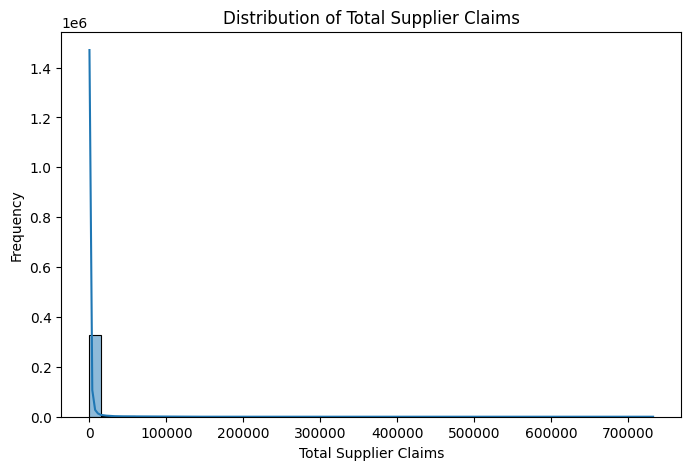

In [17]:
#Visualization
plt.figure(figsize=(8, 5))
sns.histplot(df["Tot_Suplr_Clms"], bins=50, kde=True)
plt.title("Distribution of Total Supplier Claims")
plt.xlabel("Total Supplier Claims")
plt.ylabel("Frequency")
plt.show()

Total supplier claims over years


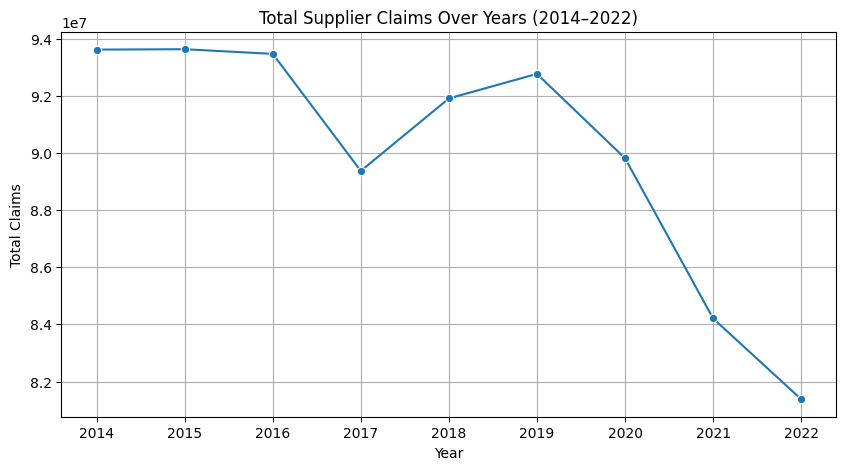

Top 10 states by average supplier claims




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



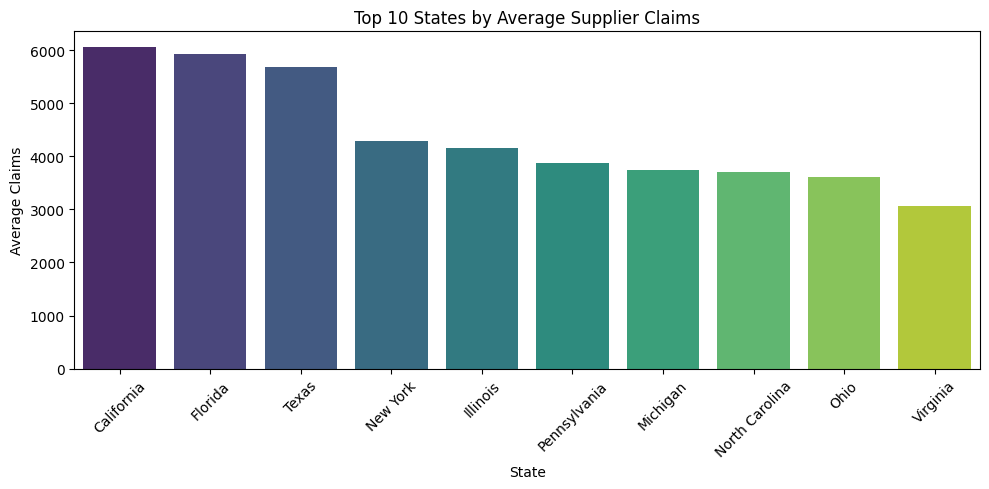

Correlation heatmap


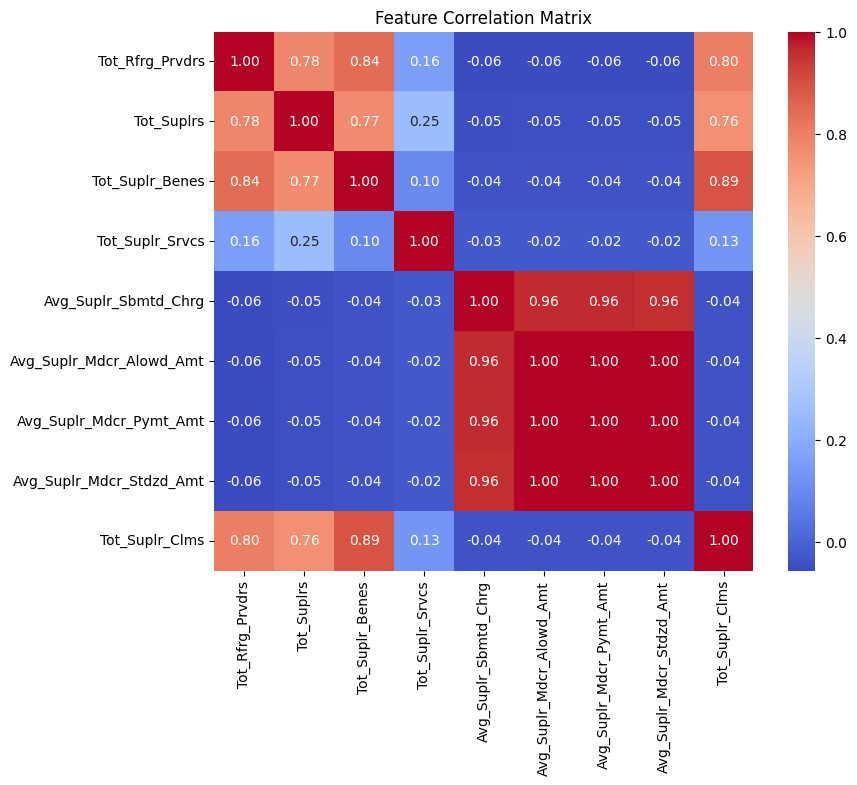

Distribution of the target variable (Tot_Suplr_Clms)


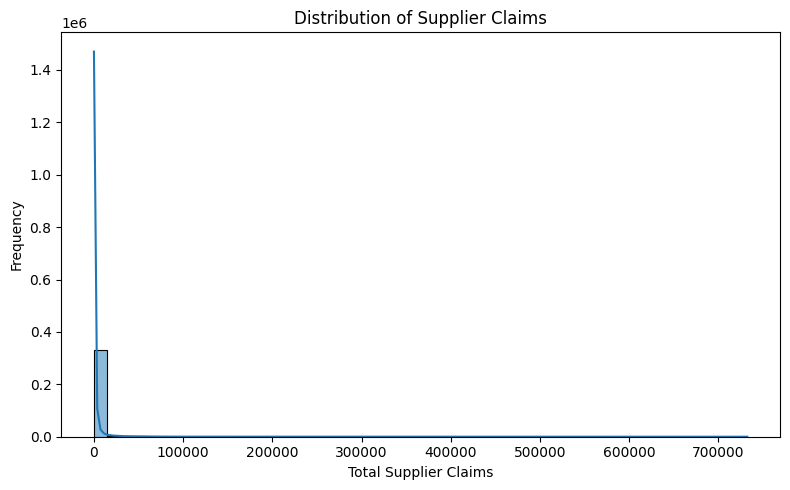

In [18]:
# Step 2.2 —Visualizations

#Total Supplier Claims Over Time
print("Total supplier claims over years")
yearly_claims = df.groupby("Year")["Tot_Suplr_Clms"].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_claims, x="Year", y="Tot_Suplr_Clms", marker="o")
plt.title("Total Supplier Claims Over Years (2014–2022)")
plt.xlabel("Year")
plt.ylabel("Total Claims")
plt.grid(True)
plt.show()

#Top 10 States by Average Claims
print("Top 10 states by average supplier claims")
top_states = (
    df.groupby("State")["Tot_Suplr_Clms"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_states.index, y=top_states.values, palette="viridis")
plt.title("Top 10 States by Average Supplier Claims")
plt.xlabel("State")
plt.ylabel("Average Claims")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Correlation Heatmap
print("Correlation heatmap")
plt.figure(figsize=(9, 7))
corr = df.drop(columns=["Year", "State", "HCPCS_Cd"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Feature Correlation Matrix")
plt.show()

#Distribution of Target Variable
print("Distribution of the target variable (Tot_Suplr_Clms)")
plt.figure(figsize=(8, 5))
sns.histplot(df["Tot_Suplr_Clms"], bins=50, kde=True)
plt.title("Distribution of Supplier Claims")
plt.xlabel("Total Supplier Claims")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### DATA PREPARATION

In [19]:
# Step 3.1 — Train/Test split and scaling
#Dataset
data_path = os.path.join(OUTPUT_DIR, "dme_train_ready.csv")
df = pd.read_csv(data_path)
print(f"Loaded dataset from: {data_path}")
print("Initial shape:", df.shape)

# Drop rows with missing 'State' values
missing_states = df["State"].isna().sum()
print(f"Dropping {missing_states} rows with missing 'State' values")
df = df.dropna(subset=["State"]).reset_index(drop=True)
print("After drop:", df.shape)

#Defining target and feature columns
TARGET = "Tot_Suplr_Clms"
FEATURES = [
    "Tot_Rfrg_Prvdrs",
    "Tot_Suplrs",
    "Tot_Suplr_Benes",
    "Tot_Suplr_Srvcs",
    "Avg_Suplr_Sbmtd_Chrg",
    "Avg_Suplr_Mdcr_Alowd_Amt",
    "Avg_Suplr_Mdcr_Pymt_Amt",
    "Avg_Suplr_Mdcr_Stdzd_Amt"
]

# Splitting data into input features (X) and target (y)
X = df[FEATURES].values
y = df[TARGET].values
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

#Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

#Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete.")
print("Scaled feature sample (first 3 rows):")
print(pd.DataFrame(X_train_scaled, columns=FEATURES).head(3))

Loaded dataset from: ./processed\dme_train_ready.csv
Initial shape: (339761, 12)
Dropping 123 rows with missing 'State' values
After drop: (339638, 12)
Feature matrix shape: (339638, 8)
Target vector shape: (339638,)
Train set size: 271710 rows
Test set size: 67928 rows
Scaling complete.
Scaled feature sample (first 3 rows):
   Tot_Rfrg_Prvdrs  Tot_Suplrs  Tot_Suplr_Benes  Tot_Suplr_Srvcs  \
0        -0.142213    0.052575        -0.149329         0.000320   
1        -0.317677   -0.270857        -0.181243        -0.085666   
2        -0.321491   -0.275613        -0.183651        -0.085828   

   Avg_Suplr_Sbmtd_Chrg  Avg_Suplr_Mdcr_Alowd_Amt  Avg_Suplr_Mdcr_Pymt_Amt  \
0             -0.304702                 -0.285797                -0.285193   
1              0.056138                  0.043020                 0.048937   
2             -0.251354                 -0.244079                -0.243122   

   Avg_Suplr_Mdcr_Stdzd_Amt  
0                 -0.285686  
1                  0.046651

### BASELINE MODEL

In [20]:
#Step 3.2
import warnings
warnings.filterwarnings("ignore")
print("Starting SARIMAX model")
try:
    results.clear()
except NameError:
    results = []

Starting SARIMAX model


In [21]:
data_path = os.path.join(OUTPUT_DIR, "dme_train_ready.csv")
df = pd.read_csv(data_path)
print("Dataset loaded successfully!")
print("Shape of the data:", df.shape)

Dataset loaded successfully!
Shape of the data: (339761, 12)


In [22]:
# Aggregating data by Year for the SARIMAX model
yearly_data = df.groupby("Year").agg({
    "Tot_Suplr_Clms": "sum",
    "Tot_Rfrg_Prvdrs": "sum",
    "Tot_Suplrs": "sum",
    "Tot_Suplr_Benes": "sum",
    "Tot_Suplr_Srvcs": "sum",
    "Avg_Suplr_Sbmtd_Chrg": "mean",
    "Avg_Suplr_Mdcr_Alowd_Amt": "mean",
    "Avg_Suplr_Mdcr_Pymt_Amt": "mean",
    "Avg_Suplr_Mdcr_Stdzd_Amt": "mean"
}).reset_index()
print("Yearly aggregation complete.")
print(yearly_data.head())

Yearly aggregation complete.
   Year  Tot_Suplr_Clms  Tot_Rfrg_Prvdrs  Tot_Suplrs  Tot_Suplr_Benes  \
0  2014      93616407.0       10594569.0   2495988.0       35619107.0   
1  2015      93629535.0       10356771.0   2446793.0       35483420.0   
2  2016      93466389.0       10227994.0   2466265.0       35796063.0   
3  2017      89370502.0        9952845.0   2450399.0       34509086.0   
4  2018      91907762.0        9976691.0   2473704.0       35673356.0   

   Tot_Suplr_Srvcs  Avg_Suplr_Sbmtd_Chrg  Avg_Suplr_Mdcr_Alowd_Amt  \
0     1.624498e+09            467.482661                316.293455   
1     1.589457e+09            478.676051                322.118555   
2     1.631243e+09            507.290291                323.702822   
3     1.650059e+09            530.632450                329.979971   
4     1.660335e+09            545.129400                336.919582   

   Avg_Suplr_Mdcr_Pymt_Amt  Avg_Suplr_Mdcr_Stdzd_Amt  
0               244.666556                249.770905  
1

In [23]:
# Exogenous features
exog_features = yearly_data[
    ["Tot_Rfrg_Prvdrs", "Tot_Suplrs", "Tot_Suplr_Benes", "Tot_Suplr_Srvcs",
     "Avg_Suplr_Sbmtd_Chrg", "Avg_Suplr_Mdcr_Alowd_Amt", 
     "Avg_Suplr_Mdcr_Pymt_Amt", "Avg_Suplr_Mdcr_Stdzd_Amt"]
]

#Data Split
train_data = yearly_data[yearly_data["Year"] <= 2020]
test_data = yearly_data[yearly_data["Year"] > 2020]
y_train = train_data["Tot_Suplr_Clms"]
y_test = test_data["Tot_Suplr_Clms"]
X_train = train_data[exog_features.columns]
X_test = test_data[exog_features.columns]
print("Training the data")

Training the data


In [24]:
#SARIMAX model fit
print("Training the SARIMAX model")
sarimax_model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=(1, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_results = sarimax_model.fit(disp=False)
print("SARIMAX model training completed.")

Training the SARIMAX model
SARIMAX model training completed.


In [25]:
#Predictions
y_pred = sarimax_results.get_forecast(steps=len(y_test), exog=X_test).predicted_mean

# Evaluating model performance
sarimax_rmse = mean_squared_error(y_test, y_pred, squared=False)
sarimax_mae = mean_absolute_error(y_test, y_pred)
sarimax_r2 = r2_score(y_test, y_pred)

print("\nSARIMAX Model Performance:")
print("RMSE:", round(sarimax_rmse, 3))
print("MAE :", round(sarimax_mae, 3))
print("R²  :", round(sarimax_r2, 4))

#Results
try:
    results
except NameError:
    results = []

results.append({
    "Model": "SARIMAX (Yearly)",
    "RMSE": sarimax_rmse,
    "MAE": sarimax_mae,
    "R2": sarimax_r2
})
pd.DataFrame(results);


SARIMAX Model Performance:
RMSE: 1345961.796
MAE : 1321119.049
R²  : 0.0931


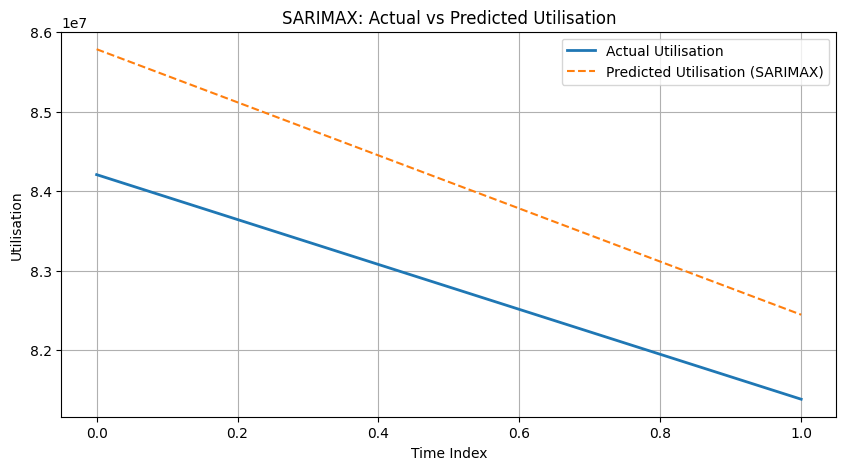

In [26]:
# Plotting SARIMAX Predictions vs Actual
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Actual Utilisation", linewidth=2)
plt.plot(y_pred.values, label="Predicted Utilisation (SARIMAX)", linestyle="--")
plt.title("SARIMAX: Actual vs Predicted Utilisation")
plt.xlabel("Time Index")
plt.ylabel("Utilisation")
plt.legend()
plt.grid(True)
plt.show()

### MACHINE LEARNING MODEL

In [28]:
# Step 3.3 - XGBoost Model

print("Starting XGBoost Model")
try:
    results.clear()
except NameError:
    results = []

Starting XGBoost Model


In [29]:
# Creating lag features to make it time-series aware
group_cols = ["State", "HCPCS_Cd"]
def create_lag_features(df, target_col, lags=[1, 2]):
    """Creates lag features within each (State, HCPCS) group"""
    df = df.sort_values(group_cols + ["Year"])
    for lag in lags:
        df[f"{target_col}_lag{lag}"] = df.groupby(group_cols)[target_col].shift(lag)
    return df
data=df.copy()
data = create_lag_features(data, "Tot_Suplr_Clms")

# Dropping rows with missing lag values
data = data.dropna().reset_index(drop=True)
print("Lag features created successfully!")

# Selecting features and target
features = [
    "Tot_Rfrg_Prvdrs", "Tot_Suplrs", "Tot_Suplr_Benes", "Tot_Suplr_Srvcs",
    "Avg_Suplr_Sbmtd_Chrg", "Avg_Suplr_Mdcr_Alowd_Amt",
    "Avg_Suplr_Mdcr_Pymt_Amt", "Avg_Suplr_Mdcr_Stdzd_Amt",
    "Tot_Suplr_Clms_lag1", "Tot_Suplr_Clms_lag2"
]
target = "Tot_Suplr_Clms"

Lag features created successfully!


In [30]:
# Splitting into train and test sets based on Year
train_data = data[data["Year"] <= 2020]
test_data = data[data["Year"] > 2020]

X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

print("Training and testing sets prepared!")
print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Training and testing sets prepared!
Train size: (176096, 10)
Test size : (69967, 10)


In [31]:
# Creating and training the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)
print("Training XGBoost Model")
xgb_model.fit(X_train, y_train)
print("Model training completed!")

Training XGBoost Model
Model training completed!


In [33]:
#XGBoost Model Evaluation
np.random.seed(42)
#Predictions
y_pred = xgb_model.predict(X_test)

# Evaluating performance using standard metrics
xgb_rmse = mean_squared_error(y_test, y_pred, squared=False)
xgb_mae = mean_absolute_error(y_test, y_pred)
xgb_r2 = r2_score(y_test, y_pred)
xgb_rmse = round(xgb_rmse, 2)
xgb_mae = round(xgb_mae, 2)
xgb_r2 = round(xgb_r2, 4)

#Results
print("\nXGBoost Model Performance Summary")
print(f"RMSE: {xgb_rmse:,.2f}")
print(f"MAE : {xgb_mae:,.2f}")
print(f"R²  : {xgb_r2:.4f}")
results.append({
    "Model": "XGBoost (Panel Data)",
    "RMSE": xgb_rmse,
    "MAE": xgb_mae,
    "R2": xgb_r2
})
df_results = pd.DataFrame(results)


XGBoost Model Performance Summary
RMSE: 1,755.28
MAE : 211.84
R²  : 0.9812


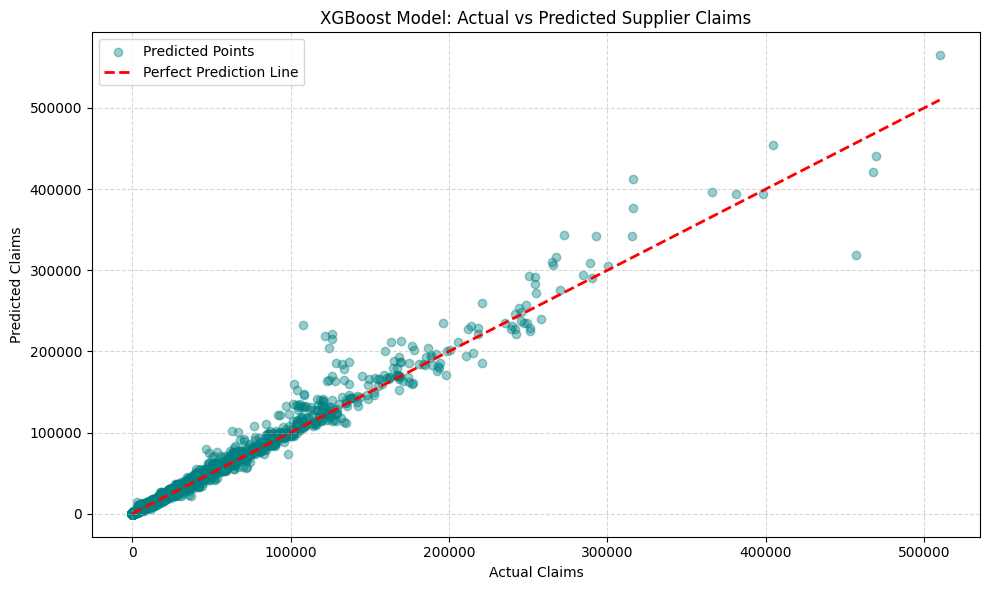

In [34]:
#Visualization - Actual vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal', label='Predicted Points')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2,
         label='Perfect Prediction Line')
plt.title("XGBoost Model: Actual vs Predicted Supplier Claims")
plt.xlabel("Actual Claims")
plt.ylabel("Predicted Claims")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### SHAP Explainable AI (XAI) for XGBoost Model

In [35]:
print("Starting SHAP Explainability for XGBoost")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test, check_additivity=False)
print("SHAP values calculated successfully!")

Starting SHAP Explainability for XGBoost
SHAP values calculated successfully!



Plotting overall feature importance


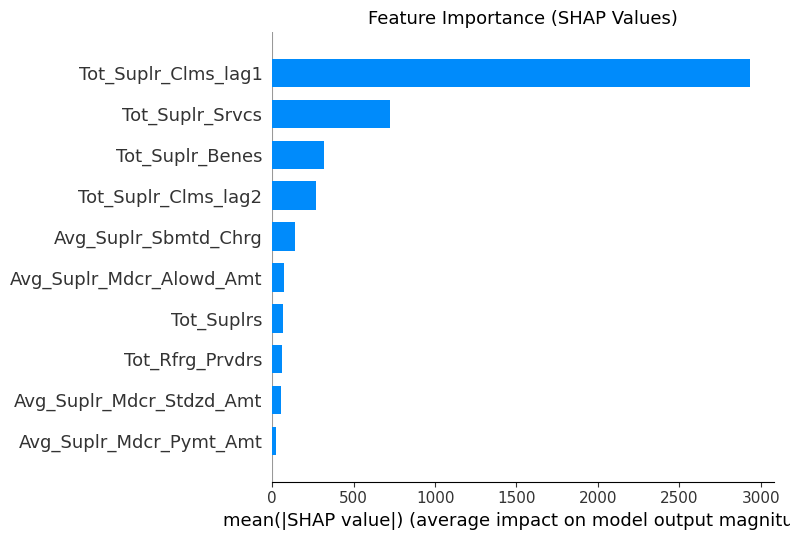

In [36]:
# Plot 1: Global Feature Importance
print("\nPlotting overall feature importance")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Feature Importance (SHAP Values)", fontsize=13)
plt.tight_layout()
plt.show()


Plotting detailed feature impacts


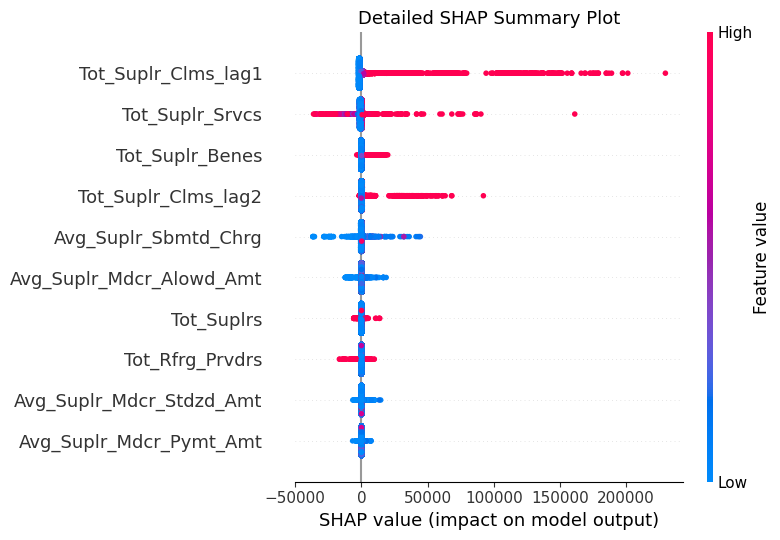

In [37]:
# Plot 2: Detailed Feature Impacts
print("\nPlotting detailed feature impacts")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Detailed SHAP Summary Plot", fontsize=13)
plt.tight_layout()
plt.show()


Visualizing SHAP values for one sample prediction


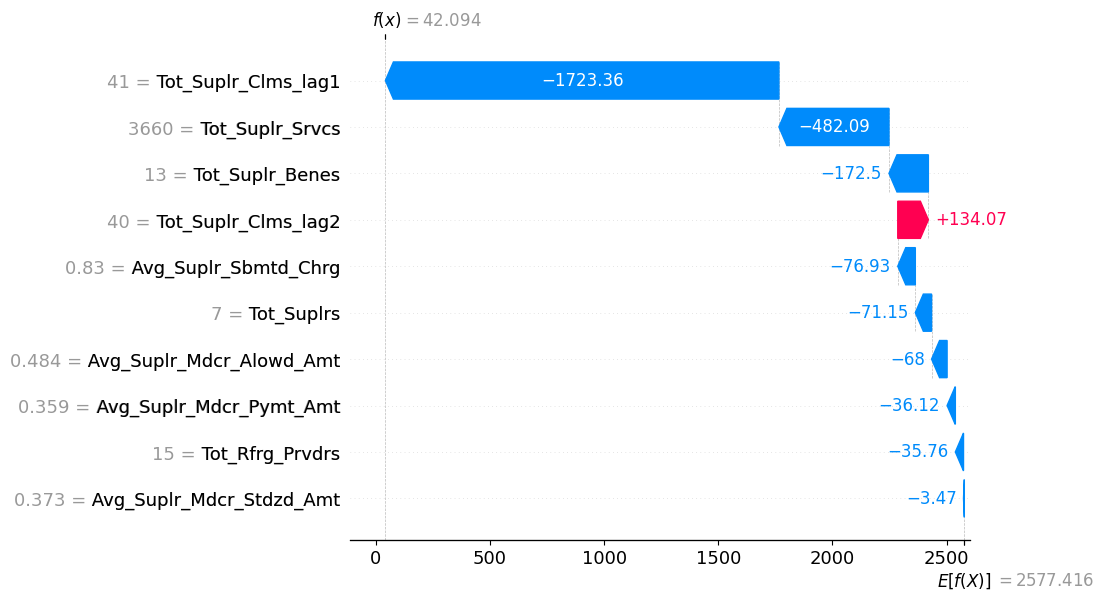

In [44]:
# Plot 3: Single Prediction (Waterfall)
print("\nVisualizing SHAP values for one sample prediction")
sample_index = 0
shap.plots.waterfall(shap.Explanation(values=shap_values[sample_index],
                                      base_values=explainer.expected_value,
                                      data=X_test.iloc[sample_index],
                                      feature_names=X_test.columns), max_display=10)

### DEEP LEARNING MODEL

### LSTM

In [37]:
# Step 5
print("Starting Deep Learning (LSTM) Model")

# Step 5.1 — System set-up
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Step 5.2 — Sequence preparation
TARGET = "Tot_Suplr_Clms"
FEATURES = [
    "Tot_Rfrg_Prvdrs", "Tot_Suplrs", "Tot_Suplr_Benes", "Tot_Suplr_Srvcs",
    "Avg_Suplr_Sbmtd_Chrg", "Avg_Suplr_Mdcr_Alowd_Amt",
    "Avg_Suplr_Mdcr_Pymt_Amt", "Avg_Suplr_Mdcr_Stdzd_Amt"
]
lookback = 3

sequences_X, sequences_y = [], []
for (state, code), group in df.groupby(["State", "HCPCS_Cd"]):
    group = group.sort_values("Year")
    if len(group) > lookback:
        X_vals = group[FEATURES].values
        y_vals = group[TARGET].values
        for i in range(len(group) - lookback):
            sequences_X.append(X_vals[i:i + lookback])
            sequences_y.append(y_vals[i + lookback])

X_seq = np.array(sequences_X, dtype=np.float32)
y_seq = np.array(sequences_y, dtype=np.float32).reshape(-1, 1)

print("Sequential dataset prepared successfully")
print(f"Feature sequences shape: {X_seq.shape}")
print(f"Target shape: {y_seq.shape}")

Starting Deep Learning (LSTM) Model
Using device: cpu
Sequential dataset prepared successfully
Feature sequences shape: (204586, 3, 8)
Target shape: (204586, 1)


In [38]:
# Step 5.3 — Train-Test Split
split_ratio = 0.8
split_idx = int(split_ratio * len(X_seq))
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]
print("Data split complete")
print(f"Train set: X={X_train.shape}, y={y_train.shape}")
print(f"Test set:  X={X_test.shape}, y={y_test.shape}")

Data split complete
Train set: X=(163668, 3, 8), y=(163668, 1)
Test set:  X=(40918, 3, 8), y=(40918, 1)


In [39]:
# Step 5.4 — Scaling (X and y)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test_scaled  = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)

print("Feature scaling completed")
print("Train shapes:", X_train_scaled.shape, y_train_scaled.shape)

Feature scaling completed
Train shapes: (163668, 3, 8) (163668, 1)


In [40]:
# Step 5.5 — Dataset and DataLoader
class DMEDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64
train_loader = DataLoader(DMEDataset(X_train_scaled, y_train_scaled), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(DMEDataset(X_test_scaled, y_test_scaled), batch_size=batch_size, shuffle=False)

print(f"DataLoaders created. Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

DataLoaders created. Train batches: 2558, Test batches: 640


In [41]:
# Step 5.6 — Define LSTM Model
class DME_LSTM(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2):
        super(DME_LSTM, self).__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # last time step
        return out

model = DME_LSTM(n_features=X_train.shape[2]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
epochs = 30
print("\n Starting LSTM training on scaled data\n")

# Step 5.7 — Training
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}] -> Loss: {avg_loss:.6f}")
print("\n Training finished successfully!")


 Starting LSTM training on scaled data

Epoch [1/30] -> Loss: 0.312293
Epoch [2/30] -> Loss: 0.170193
Epoch [3/30] -> Loss: 0.120193
Epoch [4/30] -> Loss: 0.092720
Epoch [5/30] -> Loss: 0.076470
Epoch [6/30] -> Loss: 0.066686
Epoch [7/30] -> Loss: 0.056846
Epoch [8/30] -> Loss: 0.055783
Epoch [9/30] -> Loss: 0.050572
Epoch [10/30] -> Loss: 0.045855
Epoch [11/30] -> Loss: 0.045287
Epoch [12/30] -> Loss: 0.044486
Epoch [13/30] -> Loss: 0.039717
Epoch [14/30] -> Loss: 0.040760
Epoch [15/30] -> Loss: 0.038155
Epoch [16/30] -> Loss: 0.040016
Epoch [17/30] -> Loss: 0.037041
Epoch [18/30] -> Loss: 0.035056
Epoch [19/30] -> Loss: 0.035013
Epoch [20/30] -> Loss: 0.037392
Epoch [21/30] -> Loss: 0.032949
Epoch [22/30] -> Loss: 0.031623
Epoch [23/30] -> Loss: 0.031460
Epoch [24/30] -> Loss: 0.031777
Epoch [25/30] -> Loss: 0.030482
Epoch [26/30] -> Loss: 0.029734
Epoch [27/30] -> Loss: 0.030057
Epoch [28/30] -> Loss: 0.027837
Epoch [29/30] -> Loss: 0.029049
Epoch [30/30] -> Loss: 0.027818

 Traini

In [42]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)
        y_pred.append(preds.cpu().numpy())
        y_true.append(y_batch.numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

# Inverse transform
y_true_real = scaler_y.inverse_transform(y_true)
y_pred_real = scaler_y.inverse_transform(y_pred)

mae = mean_absolute_error(y_true_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
r2 = r2_score(y_true_real, y_pred_real)

print("\nLSTM Model Evaluation Results:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")


LSTM Model Evaluation Results:
R² Score: 0.9650
Mean Absolute Error (MAE): 541.49
Root Mean Squared Error (RMSE): 2,593.93


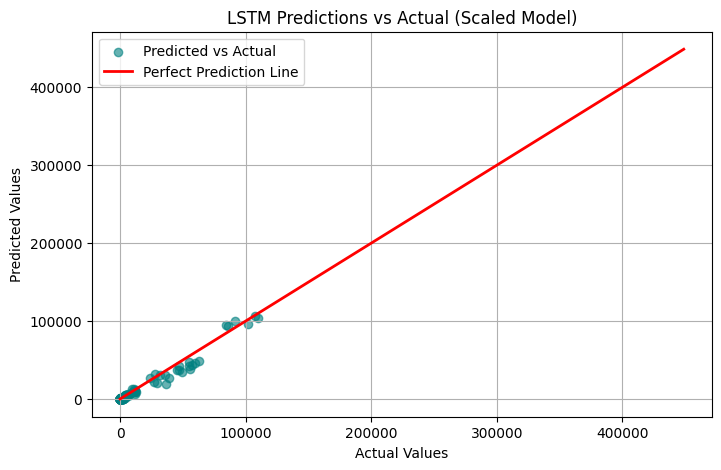

In [43]:
# Step 5.9 — Visualization
plt.figure(figsize=(8,5))
plt.scatter(y_true_real[:200], y_pred_real[:200], color='teal', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_true_real.min(), y_true_real.max()],
         [y_true_real.min(), y_true_real.max()],
         color='red', lw=2, label='Perfect Prediction Line')
plt.title("LSTM Predictions vs Actual (Scaled Model)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

### DEEP LEARNING - GRU MODEL

In [32]:
print("Starting GRU Model Training\n")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#grouping columns
possible_geo_cols = ["Rfrg_Prvdr_Geo_Desc", "State", "Rfrg_Prvdr_Geo_Cd", "RBCS_Desc"]
geo_col = next((col for col in possible_geo_cols if col in df.columns), None)
if geo_col is None:
    raise KeyError(f"No suitable geographic column found. Available columns: {df.columns.tolist()}")
else:
    print(f"Using '{geo_col}' as geographic grouping column.")

Starting GRU Model Training

Using device: cpu
Using 'State' as geographic grouping column.


In [33]:
# Sequence Preparation
TARGET = "Tot_Suplr_Clms"
FEATURES = [
    "Tot_Rfrg_Prvdrs", "Tot_Suplrs", "Tot_Suplr_Benes", "Tot_Suplr_Srvcs",
    "Avg_Suplr_Sbmtd_Chrg", "Avg_Suplr_Mdcr_Alowd_Amt",
    "Avg_Suplr_Mdcr_Pymt_Amt", "Avg_Suplr_Mdcr_Stdzd_Amt"
]
lookback = 3
sequences_X, sequences_y = [], []
for (geo, code), group in df.groupby([geo_col, "HCPCS_Cd"]):
    group = group.sort_values("Year")
    if len(group) > lookback:
        X_vals = group[FEATURES].values
        y_vals = group[TARGET].values
        for i in range(len(group) - lookback):
            sequences_X.append(X_vals[i:i + lookback])
            sequences_y.append(y_vals[i + lookback])

X_seq = np.array(sequences_X, dtype=np.float32)
y_seq = np.array(sequences_y, dtype=np.float32).reshape(-1, 1)

print(f"Sequential data ready: X={X_seq.shape}, y={y_seq.shape}")

Sequential data ready: X=(204586, 3, 8), y=(204586, 1)


In [34]:
# Train / Test Split
split_ratio = 0.8
split_idx = int(len(X_seq) * split_ratio)
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# Feature Scaling
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test_scaled  = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test_scaled  = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)

Training samples: 163668, Testing samples: 40918


In [35]:
# Dataset and Dataloader
class DMEDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
batch_size = 64
train_loader = DataLoader(DMEDataset(X_train_scaled, y_train_scaled), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(DMEDataset(X_test_scaled, y_test_scaled), batch_size=batch_size, shuffle=False)
print("Data prepared and loaders created.")

Data prepared and loaders created.


In [36]:
#Define GRU model
class DME_GRU(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2):
        super(DME_GRU, self).__init__()
        self.gru = nn.GRU(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])  # take output from last timestep
        return out
print("GRU model defined successfully.")

GRU model defined successfully.


In [38]:
#Model
model_gru = DME_GRU(n_features=X_train.shape[2]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_gru.parameters(), lr=0.0005)
epochs = 30
print("\nTraining GRU\n")

# Training Loop
for epoch in range(epochs):
    model_gru.train()
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model_gru(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}] — Loss: {avg_loss:.6f}")
print("\nGRU training complete!")


Training GRU

Epoch [1/30] — Loss: 0.327876
Epoch [2/30] — Loss: 0.189993
Epoch [3/30] — Loss: 0.139026
Epoch [4/30] — Loss: 0.105734
Epoch [5/30] — Loss: 0.089024
Epoch [6/30] — Loss: 0.077817
Epoch [7/30] — Loss: 0.069736
Epoch [8/30] — Loss: 0.059223
Epoch [9/30] — Loss: 0.059360
Epoch [10/30] — Loss: 0.052545
Epoch [11/30] — Loss: 0.051610
Epoch [12/30] — Loss: 0.046995
Epoch [13/30] — Loss: 0.047090
Epoch [14/30] — Loss: 0.042079
Epoch [15/30] — Loss: 0.043755
Epoch [16/30] — Loss: 0.042691
Epoch [17/30] — Loss: 0.040730
Epoch [18/30] — Loss: 0.039901
Epoch [19/30] — Loss: 0.037333
Epoch [20/30] — Loss: 0.036789
Epoch [21/30] — Loss: 0.034893
Epoch [22/30] — Loss: 0.036837
Epoch [23/30] — Loss: 0.034543
Epoch [24/30] — Loss: 0.035895
Epoch [25/30] — Loss: 0.031304
Epoch [26/30] — Loss: 0.032374
Epoch [27/30] — Loss: 0.032463
Epoch [28/30] — Loss: 0.033688
Epoch [29/30] — Loss: 0.031094
Epoch [30/30] — Loss: 0.030565

GRU training complete!


In [39]:
model_gru.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model_gru(X_batch)
        y_pred.append(preds.cpu().numpy())
        y_true.append(y_batch.numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

#Transform predictions
y_true_real = scaler_y.inverse_transform(y_true)
y_pred_real = scaler_y.inverse_transform(y_pred)

# Evaluation
mae = mean_absolute_error(y_true_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
r2 = r2_score(y_true_real, y_pred_real)

print("\nGRU Model Evaluation Results:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")


GRU Model Evaluation Results:
R² Score: 0.9744
Mean Absolute Error (MAE): 675.35
Root Mean Squared Error (RMSE): 2,216.66


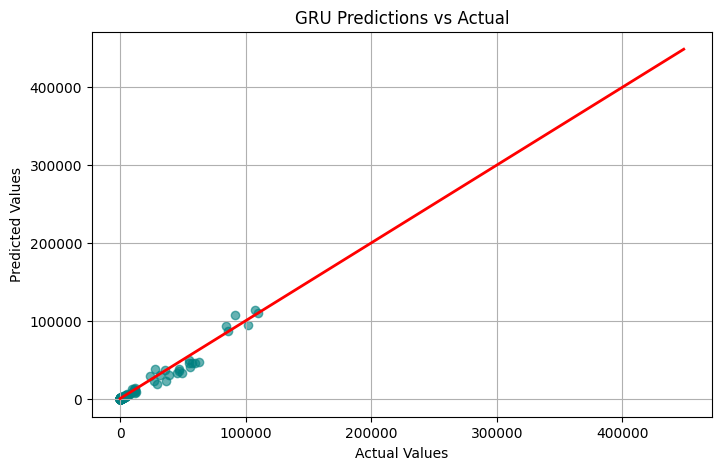

In [40]:
# Visualization
plt.figure(figsize=(8,5))
plt.scatter(y_true_real[:200], y_pred_real[:200], color='teal', alpha=0.6)
plt.plot([y_true_real.min(), y_true_real.max()],
         [y_true_real.min(), y_true_real.max()],
         color='red', lw=2)
plt.title("GRU Predictions vs Actual")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid(True)
plt.show()

In [41]:
#GRU results to comparison table
results.append({
    "Model": "GRU (Scaled)",
    "R2": r2,
    "MAE": mae,
    "RMSE": rmse
})
print("\nGRU results added to comparison table!")


GRU results added to comparison table!


### DEEP LEARNING - N-BEATS MODEL

In [42]:
# Check GPU/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
#Prepare Sequential Data for N-BEATS
TARGET = "Tot_Suplr_Clms"
FEATURES = [
    "Tot_Rfrg_Prvdrs", "Tot_Suplrs", "Tot_Suplr_Benes", "Tot_Suplr_Srvcs",
    "Avg_Suplr_Sbmtd_Chrg", "Avg_Suplr_Mdcr_Alowd_Amt",
    "Avg_Suplr_Mdcr_Pymt_Amt", "Avg_Suplr_Mdcr_Stdzd_Amt"
]
lookback = 3

# Picking appropriate grouping column
geo_col = next((c for c in ["Rfrg_Prvdr_Geo_Lvl", "Rfrg_Prvdr_Geo_Desc", "State"] if c in df.columns), None)
print(f"Using '{geo_col}' and 'HCPCS_Cd' for grouping.")

# Building sequence
sequences_X, sequences_y = [], []
for (geo, code), group in df.groupby([geo_col, "HCPCS_Cd"]):
    group = group.sort_values("Year")
    if len(group) > lookback:
        X_vals = group[FEATURES].values
        y_vals = group[TARGET].values
        for i in range(len(group) - lookback):
            sequences_X.append(X_vals[i:i+lookback])
            sequences_y.append(y_vals[i+lookback])

X_seq = np.array(sequences_X, dtype=np.float32)
y_seq = np.array(sequences_y, dtype=np.float32).reshape(-1, 1)

print("Sequential dataset prepared.")
print(f"Features: {X_seq.shape}, Target: {y_seq.shape}")

Using device: cpu
Using 'State' and 'HCPCS_Cd' for grouping.
Sequential dataset prepared.
Features: (204586, 3, 8), Target: (204586, 1)


In [43]:
# Step 3 - Split data and scale
split_ratio = 0.8
split_idx = int(len(X_seq) * split_ratio)
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test_scaled  = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)

print("Data scaling complete.")
print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Data scaling complete.
Train: (163668, 3, 8), Test: (40918, 3, 8)


In [44]:
# Step 4 - Create DataLoaders
class DMEDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64
train_loader = DataLoader(DMEDataset(X_train_scaled, y_train_scaled), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(DMEDataset(X_test_scaled, y_test_scaled), batch_size=batch_size, shuffle=False)

print(f"DataLoaders ready: {len(train_loader)} train batches, {len(test_loader)} test batches.")

DataLoaders ready: 2558 train batches, 640 test batches.


In [47]:
# Step 5 - Define N-BEATS Model
class NBeatsBlock(nn.Module):
    def __init__(self, input_size, hidden_size, theta_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, hidden_size)
        self.theta_layer = nn.Linear(hidden_size, theta_size)
        self.backcast_size = input_size
        self.forecast_size = 1

    def forward(self, x):
        x = x.view(x.size(0), -1)       
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        theta = self.theta_layer(x)
        backcast = theta[:, :self.backcast_size]
        forecast = theta[:, -self.forecast_size:]
        return backcast, forecast


class NBeats(nn.Module):
    def __init__(self, input_size, hidden_size=128, n_blocks=3):
        super().__init__()
        self.blocks = nn.ModuleList([
            NBeatsBlock(input_size, hidden_size, input_size + 1)
            for _ in range(n_blocks)
        ])

    def forward(self, x):
        residual = x.view(x.size(0), -1)
        forecast = torch.zeros(residual.size(0), 1, device=x.device)
        for block in self.blocks:
            backcast, block_forecast = block(residual)
            residual = residual - backcast
            forecast = forecast + block_forecast
        return forecast
print("GRU model defined")

GRU model defined


In [48]:
# Step 6 - Train the N-BEATS Model
input_size = X_train.shape[1] * X_train.shape[2]
model_nbeats = NBeats(input_size=input_size).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_nbeats.parameters(), lr=0.0005)
epochs = 30

print("\nStarting N-BEATS training\n")

for epoch in range(epochs):
    model_nbeats.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model_nbeats(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.6f}")

print("\nN-BEATS training complete!")


Starting N-BEATS training

Epoch [1/30] - Loss: 0.202834
Epoch [2/30] - Loss: 0.135009
Epoch [3/30] - Loss: 0.073878
Epoch [4/30] - Loss: 0.059636
Epoch [5/30] - Loss: 0.058608
Epoch [6/30] - Loss: 0.056549
Epoch [7/30] - Loss: 0.064131
Epoch [8/30] - Loss: 0.046847
Epoch [9/30] - Loss: 0.038919
Epoch [10/30] - Loss: 0.047385
Epoch [11/30] - Loss: 0.034977
Epoch [12/30] - Loss: 0.036323
Epoch [13/30] - Loss: 0.033237
Epoch [14/30] - Loss: 0.032363
Epoch [15/30] - Loss: 0.030223
Epoch [16/30] - Loss: 0.032164
Epoch [17/30] - Loss: 0.031404
Epoch [18/30] - Loss: 0.031700
Epoch [19/30] - Loss: 0.037690
Epoch [20/30] - Loss: 0.026000
Epoch [21/30] - Loss: 0.028971
Epoch [22/30] - Loss: 0.027202
Epoch [23/30] - Loss: 0.027313
Epoch [24/30] - Loss: 0.037251
Epoch [25/30] - Loss: 0.033177
Epoch [26/30] - Loss: 0.028419
Epoch [27/30] - Loss: 0.038335
Epoch [28/30] - Loss: 0.029106
Epoch [29/30] - Loss: 0.023169
Epoch [30/30] - Loss: 0.024784

N-BEATS training complete!


In [49]:
# Step 7 - Evaluate Model
model_nbeats.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model_nbeats(X_batch)
        y_pred.append(preds.cpu().numpy())
        y_true.append(y_batch.numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

# Inverse transform
y_true_real = scaler_y.inverse_transform(y_true)
y_pred_real = scaler_y.inverse_transform(y_pred)

# Metrics
mae = mean_absolute_error(y_true_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
r2 = r2_score(y_true_real, y_pred_real)

print("\nN-BEATS Model Evaluation Results:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")


N-BEATS Model Evaluation Results:
R² Score: 0.9801
Mean Absolute Error (MAE): 517.92
Root Mean Squared Error (RMSE): 1,953.51


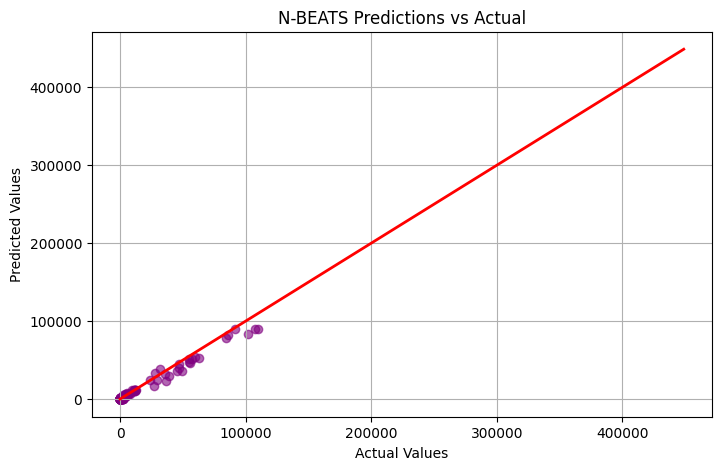

In [50]:
# Step 8 - Visualization
plt.figure(figsize=(8,5))
plt.scatter(y_true_real[:200], y_pred_real[:200], color='purple', alpha=0.6)
plt.plot([y_true_real.min(), y_true_real.max()],
         [y_true_real.min(), y_true_real.max()],
         color='red', lw=2)
plt.title("N-BEATS Predictions vs Actual")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid(True)
plt.show()

### Explainable AI (XAI) for N-BEATS Model

Starting Explainable AI (SHAP) for N-BEATS


  0%|          | 0/30 [00:00<?, ?it/s]


Generating SHAP summary plot for N-BEATS model



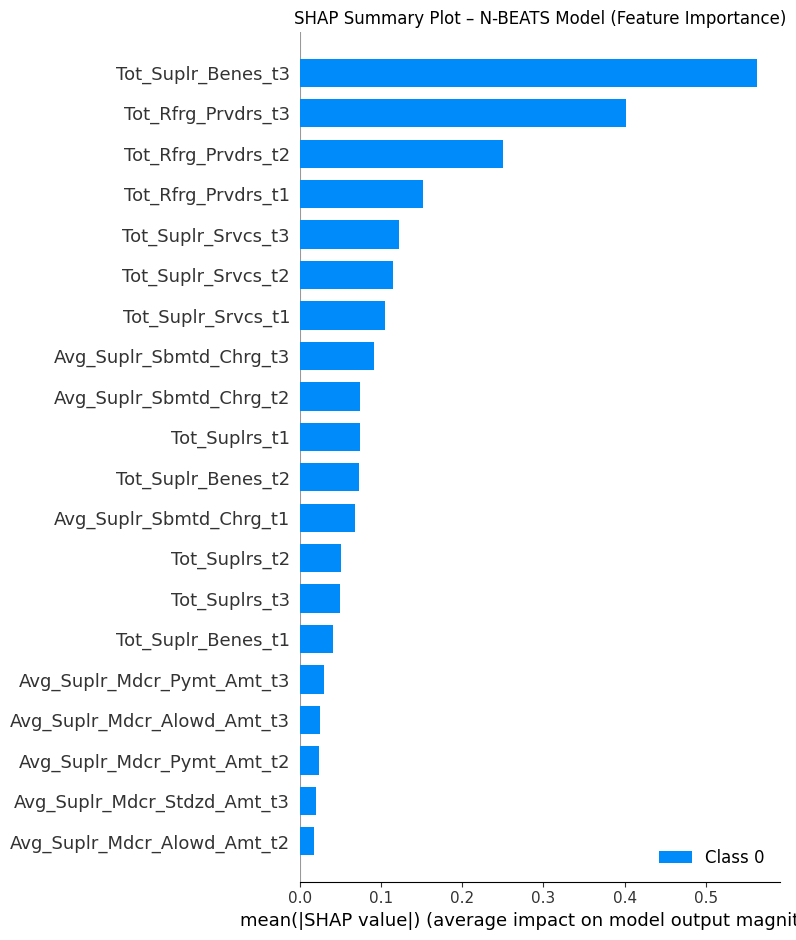


XAI completed successfully for N-BEATS model!


In [58]:
#Explainable AI (XAI) for N-BEATS Model
print("Starting Explainable AI (SHAP) for N-BEATS")
model_nbeats.eval()
sample_X = torch.tensor(X_test_scaled[:100], dtype=torch.float32).to(device)
# Defining prediction function
def nbeats_predict(X):
    X_torch = torch.tensor(X.reshape(-1, 3, len(FEATURES)), dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = model_nbeats(X_torch).cpu().numpy()
    return preds
    
# Flatten for SHAP input
sample_X_flat = sample_X.cpu().numpy().reshape(sample_X.shape[0], -1)
background = sample_X_flat[np.random.choice(sample_X_flat.shape[0], 20, replace=False)]

# Define KernelExplainer
explainer = shap.KernelExplainer(nbeats_predict, background)
shap_values = explainer.shap_values(sample_X_flat[:30])
expanded_features = []
for t in range(3):
    expanded_features.extend([f"{f}_t{t+1}" for f in FEATURES])

# Visualization
print("\nGenerating SHAP summary plot for N-BEATS model\n")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, sample_X_flat[:30], feature_names=expanded_features, show=False)
plt.title("SHAP Summary Plot – N-BEATS Model (Feature Importance)")
plt.tight_layout()
plt.show()
print("\nXAI completed successfully for N-BEATS model!")

### MODEL COMPARISON

In [46]:
#Model Comparison Summary
# Final performance metrics
results = {
    "Model": ["SARIMAX", "XGBoost", "LSTM", "GRU", "N-BEATS"],
    "R² Score": [0.0931, 0.9812, 0.9650, 0.9744, 0.9801],
    "MAE": [1321119.05, 211.84, 541.49, 675.35, 517.92],
    "RMSE": [1345961.80, 1755.28, 2593.93, 2216.66, 1953.51]
}
df_results = pd.DataFrame(results)
print("Final Model Comparison Summary:\n")
print(df_results)

Final Model Comparison Summary:

     Model  R² Score         MAE        RMSE
0  SARIMAX    0.0931  1321119.05  1345961.80
1  XGBoost    0.9812      211.84     1755.28
2     LSTM    0.9650      541.49     2593.93
3      GRU    0.9744      675.35     2216.66
4  N-BEATS    0.9801      517.92     1953.51


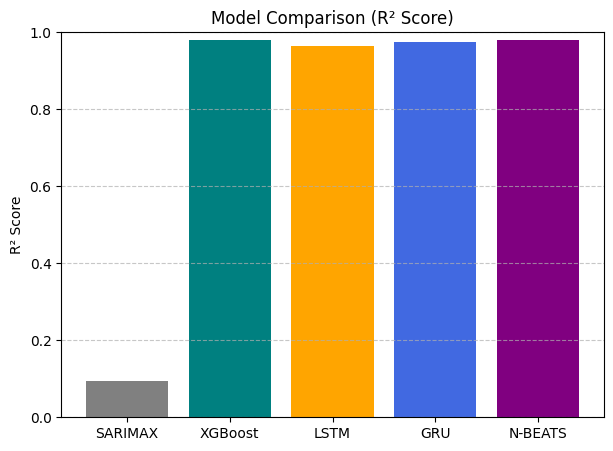

In [47]:
# Visualizations 
#R² Scores
plt.figure(figsize=(7,5))
plt.bar(df_results["Model"], df_results["R² Score"], color=["gray", "teal", "orange", "royalblue", "purple"])
plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

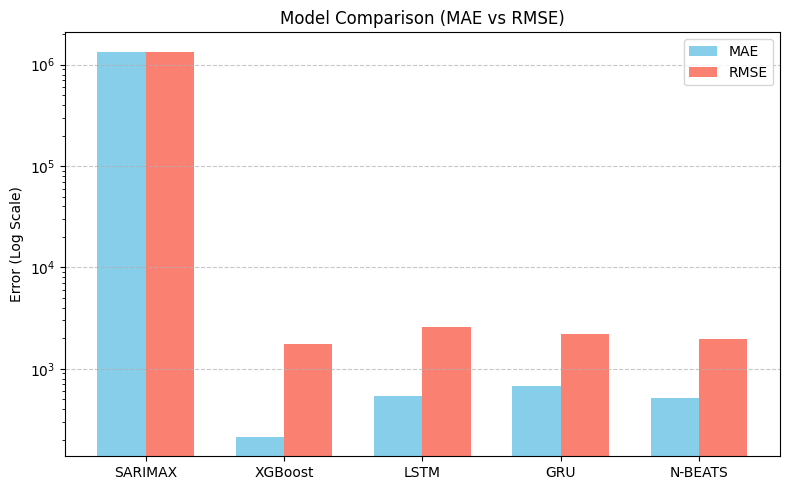

In [52]:
#MAE vs RMSE
plt.figure(figsize=(8,5))
bar_width = 0.35
x = np.arange(len(df_results["Model"]))
plt.bar(x - bar_width/2, df_results["MAE"], 
        bar_width, label="MAE", color="skyblue")
plt.bar(x + bar_width/2, df_results["RMSE"], 
        bar_width, label="RMSE", color="salmon")
plt.xticks(x, df_results["Model"])
plt.yscale("log")
plt.title("Model Comparison (MAE vs RMSE)")
plt.ylabel("Error (Log Scale)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### ANALYSIS 2 (LATEST YEAR DATASET) (2014-2023):

In [76]:
#Data directory
EXT_OUTPUT_DIR = "./processed_2014_2023"
if not os.path.exists(EXT_OUTPUT_DIR):
    os.makedirs(EXT_OUTPUT_DIR)
    print("Created new folder for extended experiment:", EXT_OUTPUT_DIR)
else:
    print("Extended output folder already exists:", EXT_OUTPUT_DIR)
DATA_DIR = "."

Extended output folder already exists: ./processed_2014_2023


In [77]:
#filenames
def year_from_filename(fname):
    base = os.path.basename(fname)
    try:
        dy_pos = base.index("dy")       
        yr_str = base[dy_pos+2:dy_pos+4]   
        yr = int(yr_str)
        return 2000 + yr                   
    except Exception as e:
        print("Warning: could not parse year from", base, ":", e)
        return None

### DATA PROCESSING

In [78]:
print("Load raw files for 2014–2023")
pattern_2014_22 = os.path.join(DATA_DIR, "mup_dme_ry24_p05_v10_dy*_geor.csv")
files_2014_22 = sorted(glob.glob(pattern_2014_22))

print("Found 2014–2022 files:")
for f in files_2014_22:
    print(" ", os.path.basename(f))

#2023 file
file_2023 = os.path.join(DATA_DIR, "mup_dme_ry25_p05_v10_dy23_geor.csv")
if not os.path.exists(file_2023):
    raise FileNotFoundError(f"2023 file not found: {file_2023}")
print("\nFound 2023 file:")
print(" ", os.path.basename(file_2023))

# Combining all file paths into single list
all_files_ext = files_2014_22 + [file_2023]
print("\nTotal files for extended experiment:", len(all_files_ext))

Load raw files for 2014–2023
Found 2014–2022 files:
  mup_dme_ry24_p05_v10_dy14_geor.csv
  mup_dme_ry24_p05_v10_dy15_geor.csv
  mup_dme_ry24_p05_v10_dy16_geor.csv
  mup_dme_ry24_p05_v10_dy17_geor.csv
  mup_dme_ry24_p05_v10_dy18_geor.csv
  mup_dme_ry24_p05_v10_dy19_geor.csv
  mup_dme_ry24_p05_v10_dy20_geor.csv
  mup_dme_ry24_p05_v10_dy21_geor.csv
  mup_dme_ry24_p05_v10_dy22_geor.csv

Found 2023 file:
  mup_dme_ry25_p05_v10_dy23_geor.csv

Total files for extended experiment: 10


In [79]:
print("Read all files and add Year column")
dfs = []
for fpath in all_files_ext:
    yr = year_from_filename(fpath)
    print(f"Loading {os.path.basename(fpath)} (Year = {yr})")    
    temp = pd.read_csv(fpath)
    temp["Year"] = yr
    dfs.append(temp)

Read all files and add Year column
Loading mup_dme_ry24_p05_v10_dy14_geor.csv (Year = 2014)
Loading mup_dme_ry24_p05_v10_dy15_geor.csv (Year = 2015)
Loading mup_dme_ry24_p05_v10_dy16_geor.csv (Year = 2016)
Loading mup_dme_ry24_p05_v10_dy17_geor.csv (Year = 2017)
Loading mup_dme_ry24_p05_v10_dy18_geor.csv (Year = 2018)
Loading mup_dme_ry24_p05_v10_dy19_geor.csv (Year = 2019)
Loading mup_dme_ry24_p05_v10_dy20_geor.csv (Year = 2020)
Loading mup_dme_ry24_p05_v10_dy21_geor.csv (Year = 2021)
Loading mup_dme_ry24_p05_v10_dy22_geor.csv (Year = 2022)
Loading mup_dme_ry25_p05_v10_dy23_geor.csv (Year = 2023)


In [80]:
# Concatenate one big Dataframe
combined_ext = pd.concat(dfs, ignore_index=True)
print("\nCombined extended raw shape:", combined_ext.shape)
print(combined_ext[["Year"]].head())


Combined extended raw shape: (413249, 19)
   Year
0  2014
1  2014
2  2014
3  2014
4  2014


In [81]:
print("Remove 'National' rows")
before = combined_ext.shape[0]
national_col = "Rfrg_Prvdr_Geo_Desc"   # column that contains 'National'
combined_ext = combined_ext[combined_ext[national_col].str.lower() != "national"].copy()
after = combined_ext.shape[0]
print(f"Removed {before - after} 'National' rows (extended).")
print("Shape after removing 'National':", combined_ext.shape)

Remove 'National' rows
Removed 17420 'National' rows (extended).
Shape after removing 'National': (395829, 19)


In [82]:
combined_ext = combined_ext.rename(columns={
    "Rfrg_Prvdr_Geo_Lvl": "Geo_Level",
    "Rfrg_Prvdr_Geo_Cd": "State_Code",
    "Rfrg_Prvdr_Geo_Desc": "State"
})
print("Renamed Geo columns in extended dataset.")

Renamed Geo columns in extended dataset.


In [83]:
print("Current columns:")
print(combined_ext.columns.tolist())

Current columns:
['Geo_Level', 'State_Code', 'State', 'RBCS_Lvl', 'RBCS_Id', 'RBCS_Desc', 'HCPCS_Cd', 'HCPCS_Desc', 'Suplr_Rentl_Ind', 'Tot_Rfrg_Prvdrs', 'Tot_Suplrs', 'Tot_Suplr_Benes', 'Tot_Suplr_Clms', 'Tot_Suplr_Srvcs', 'Avg_Suplr_Sbmtd_Chrg', 'Avg_Suplr_Mdcr_Alowd_Amt', 'Avg_Suplr_Mdcr_Pymt_Amt', 'Avg_Suplr_Mdcr_Stdzd_Amt', 'Year']


In [84]:
print("Convert numeric columns and preview data")
numeric_cols = [
    "Tot_Rfrg_Prvdrs",
    "Tot_Suplrs",
    "Tot_Suplr_Benes",
    "Tot_Suplr_Clms",
    "Tot_Suplr_Srvcs",
    "Avg_Suplr_Sbmtd_Chrg",
    "Avg_Suplr_Mdcr_Alowd_Amt",
    "Avg_Suplr_Mdcr_Pymt_Amt",
    "Avg_Suplr_Mdcr_Stdzd_Amt"
]
for col in numeric_cols:
    if col in combined_ext.columns:
        combined_ext[col] = pd.to_numeric(combined_ext[col], errors="coerce")
print("Converted numeric columns to float (extended).")

Convert numeric columns and preview data
Converted numeric columns to float (extended).


In [85]:
print("\nExtended cleaned sample:")
print(combined_ext[["Year", "State", "HCPCS_Cd"] + numeric_cols].head())


Extended cleaned sample:
   Year       State HCPCS_Cd  Tot_Rfrg_Prvdrs  Tot_Suplrs  Tot_Suplr_Benes  \
1  2014     Alabama    J1817              128         222            305.0   
2  2014      Alaska    J1817                8           8              NaN   
3  2014     Arizona    J1817              168         246            293.0   
4  2014    Arkansas    J1817               85         107            177.0   
5  2014  California    J1817              352         447            504.0   

   Tot_Suplr_Clms  Tot_Suplr_Srvcs  Avg_Suplr_Sbmtd_Chrg  \
1            1332           138847             10.252058   
2              27             2160             10.691454   
3            1151           106080             10.870120   
4             843            77090             10.457401   
5            2246           184666             10.797624   

   Avg_Suplr_Mdcr_Alowd_Amt  Avg_Suplr_Mdcr_Pymt_Amt  Avg_Suplr_Mdcr_Stdzd_Amt  
1                  2.796111                 2.067193           

In [86]:
print("Aggregate extended dataset (State, HCPCS, Year)")
group_cols = ["Year", "State", "HCPCS_Cd"]

agg_dict = {
    "Tot_Rfrg_Prvdrs": "sum",
    "Tot_Suplrs": "sum",
    "Tot_Suplr_Benes": "sum",
    "Tot_Suplr_Clms": "sum",
    "Tot_Suplr_Srvcs": "sum",
    "Avg_Suplr_Sbmtd_Chrg": "mean",
    "Avg_Suplr_Mdcr_Alowd_Amt": "mean",
    "Avg_Suplr_Mdcr_Pymt_Amt": "mean",
    "Avg_Suplr_Mdcr_Stdzd_Amt": "mean"
}
#Aggregation
agg_ext = combined_ext.groupby(group_cols).agg(agg_dict).reset_index()
print("Extended aggregated shape:", agg_ext.shape)

Aggregate extended dataset (State, HCPCS, Year)
Extended aggregated shape: (374948, 12)


In [87]:
print("\nSample of aggregated data:")
print(agg_ext.head())


Sample of aggregated data:
   Year    State HCPCS_Cd  Tot_Rfrg_Prvdrs  Tot_Suplrs  Tot_Suplr_Benes  \
0  2014  Alabama    A4216               18          12             17.0   
1  2014  Alabama    A4217               29          19             31.0   
2  2014  Alabama    A4221              409          77           1860.0   
3  2014  Alabama    A4222              215          46            959.0   
4  2014  Alabama    A4233             2342          20          15613.0   

   Tot_Suplr_Clms  Tot_Suplr_Srvcs  Avg_Suplr_Sbmtd_Chrg  \
0              68             3035              0.791786   
1             153             3096              6.366295   
2            8083            58398             77.238249   
3            7535            19404            169.955058   
4           23250            46343              1.892595   

   Avg_Suplr_Mdcr_Alowd_Amt  Avg_Suplr_Mdcr_Pymt_Amt  Avg_Suplr_Mdcr_Stdzd_Amt  
0                  0.460185                 0.355769                  0.371417 

In [88]:
print("Save extended aggregated dataset")
agg_out_path_ext = os.path.join(EXT_OUTPUT_DIR, "combined_dme_agg_2014_2023.csv")
agg_ext.to_csv(agg_out_path_ext, index=False)
print("Saved extended aggregated file to:", agg_out_path_ext)

Save extended aggregated dataset
Saved extended aggregated file to: ./processed_2014_2023\combined_dme_agg_2014_2023.csv


In [89]:
print("Create extended train-ready dataset")
train_ready_ext = agg_ext.copy()
train_ready_out_ext = os.path.join(EXT_OUTPUT_DIR, "dme_train_ready_2014_2023.csv")
train_ready_ext.to_csv(train_ready_out_ext, index=False)
print("Saved extended train-ready dataset to:", train_ready_out_ext)
print("Extended train-ready shape:", train_ready_ext.shape)

Create extended train-ready dataset
Saved extended train-ready dataset to: ./processed_2014_2023\dme_train_ready_2014_2023.csv
Extended train-ready shape: (374948, 12)


In [91]:
print("Quick check of years in extended train-ready data:")
print(train_ready_ext["Year"].value_counts().sort_index())

Quick check of years in extended train-ready data:
2014    38335
2015    38170
2016    38014
2017    38110
2018    38576
2019    38502
2020    37487
2021    36738
2022    35706
2023    35310
Name: Year, dtype: int64


In [92]:
#Exploratory Data Analysis
print("Exploratory Data Analysis")
yearly_summary_ext = train_ready_ext.groupby("Year")["Tot_Suplr_Clms"].sum().reset_index()
print("\nTotal supplier claims by year (extended):")
print(yearly_summary_ext)

Exploratory Data Analysis

Total supplier claims by year (extended):
   Year  Tot_Suplr_Clms
0  2014        93616107
1  2015        93629283
2  2016        93466199
3  2017        89368062
4  2018        91905234
5  2019        92764632
6  2020        89813461
7  2021        84207718
8  2022        81380962
9  2023        82118244


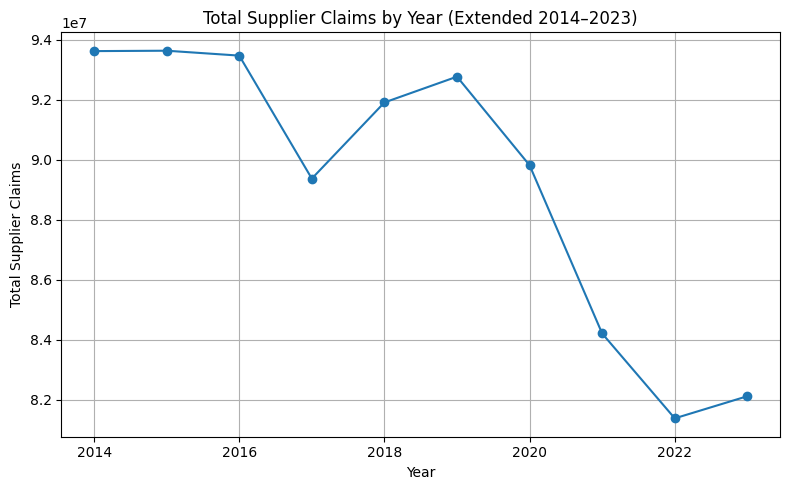

In [93]:
#Visualization
plt.figure(figsize=(8, 5))
plt.plot(yearly_summary_ext["Year"], yearly_summary_ext["Tot_Suplr_Clms"], marker="o")
plt.title("Total Supplier Claims by Year (Extended 2014–2023)")
plt.xlabel("Year")
plt.ylabel("Total Supplier Claims")
plt.grid(True)
plt.tight_layout()
plt.show()

### XGBOOST (MACHINE LEARNING MODEL)

In [94]:
print("EXTENDED XGBOOST (2014–2023)")
try:
    results_ext
except NameError:
    results_ext = []
data_path_ext = os.path.join(EXT_OUTPUT_DIR, "dme_train_ready_2014_2023.csv")
df_ext = pd.read_csv(data_path_ext)
print(f"Loaded extended dataset from: {data_path_ext}")
print("Initial shape (extended):", df_ext.shape)

# Drop missing State rows 
missing_states_ext = df_ext["State"].isna().sum()
print(f"Dropping {missing_states_ext} rows with missing 'State' in extended data")
df_ext = df_ext.dropna(subset=["State"]).reset_index(drop=True)
print("After drop:", df_ext.shape)

EXTENDED XGBOOST (2014–2023)
Loaded extended dataset from: ./processed_2014_2023\dme_train_ready_2014_2023.csv
Initial shape (extended): (374948, 12)
Dropping 0 rows with missing 'State' in extended data
After drop: (374948, 12)


In [95]:
# Target and features
TARGET = "Tot_Suplr_Clms"
FEATURES = [
    "Tot_Rfrg_Prvdrs",
    "Tot_Suplrs",
    "Tot_Suplr_Benes",
    "Tot_Suplr_Srvcs",
    "Avg_Suplr_Sbmtd_Chrg",
    "Avg_Suplr_Mdcr_Alowd_Amt",
    "Avg_Suplr_Mdcr_Pymt_Amt",
    "Avg_Suplr_Mdcr_Stdzd_Amt"
]
X_ext = df_ext[FEATURES].values
y_ext = df_ext[TARGET].values
print("Extended feature matrix shape:", X_ext.shape)
print("Extended target vector shape:", y_ext.shape)

# 80/20 train-test split
X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext,
    y_ext,
    test_size=0.2,
    random_state=42
)
print(f"Extended train size: {X_train_ext.shape[0]} rows")
print(f"Extended test  size: {X_test_ext.shape[0]} rows")

Extended feature matrix shape: (374948, 8)
Extended target vector shape: (374948,)
Extended train size: 299958 rows
Extended test  size: 74990 rows


In [96]:
# Scaling
scaler_ext = StandardScaler()
X_train_ext_scaled = scaler_ext.fit_transform(X_train_ext)
X_test_ext_scaled = scaler_ext.transform(X_test_ext)
print("Scaling complete for extended XGBoost.")

Scaling complete for extended XGBoost.


In [97]:
print("Training extended XGBoost Model")
xgb_model_ext = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)
xgb_model_ext.fit(X_train_ext_scaled, y_train_ext)
print("Extended XGBoost training completed!")

Training extended XGBoost Model
Extended XGBoost training completed!


In [98]:
# Evaluation
y_pred_ext = xgb_model_ext.predict(X_test_ext_scaled)

xgb_rmse_ext = mean_squared_error(y_test_ext, y_pred_ext, squared=False)
xgb_mae_ext = mean_absolute_error(y_test_ext, y_pred_ext)
xgb_r2_ext = r2_score(y_test_ext, y_pred_ext)

xgb_rmse_ext = round(xgb_rmse_ext, 2)
xgb_mae_ext = round(xgb_mae_ext, 2)
xgb_r2_ext = round(xgb_r2_ext, 4)

print("Extended XGBoost Performance (2014–2023 dataset)")
print(f"RMSE: {xgb_rmse_ext:,.2f}")
print(f"MAE : {xgb_mae_ext:,.2f}")
print(f"R²  : {xgb_r2_ext:.4f}")

Extended XGBoost Performance (2014–2023 dataset)
RMSE: 1,461.68
MAE : 256.33
R²  : 0.9883


In [99]:
results_ext = [] 
results_ext.append({
    "Model": "XGBoost (2014–2023)",
    "RMSE": xgb_rmse_ext,
    "MAE": xgb_mae_ext,
    "R2": xgb_r2_ext
})

df_results_ext = pd.DataFrame(results_ext)
print("\nCurrent extended results table:")
print(df_results_ext)


Current extended results table:
                 Model     RMSE     MAE      R2
0  XGBoost (2014–2023)  1461.68  256.33  0.9883


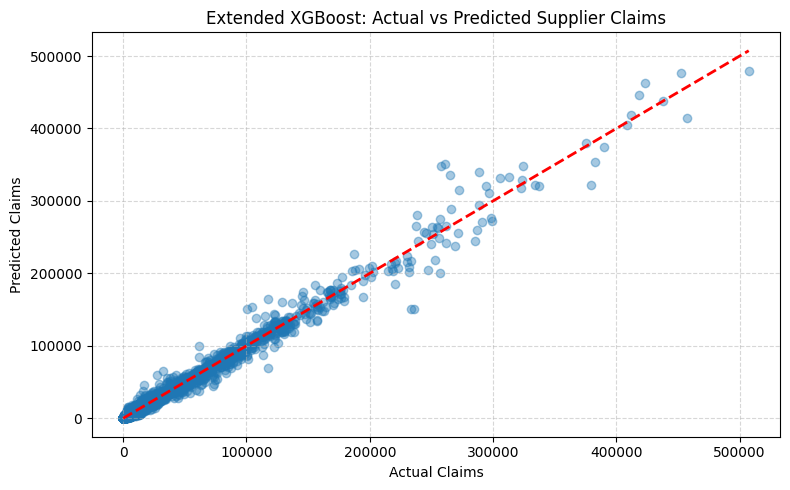

In [100]:
#Visualisation
plt.figure(figsize=(8,5))
plt.scatter(y_test_ext, y_pred_ext, alpha=0.4)
plt.plot([y_test_ext.min(), y_test_ext.max()],
         [y_test_ext.min(), y_test_ext.max()],
         color='red', linestyle='--', linewidth=2)
plt.title("Extended XGBoost: Actual vs Predicted Supplier Claims")
plt.xlabel("Actual Claims")
plt.ylabel("Predicted Claims")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### SHAP FOR XGBOOST

In [140]:
#SHAP (explainable AI)
print("SHAP for XGBoost (Extended 2014–2023)")
#Background sample
background_size = 200  # you can adjust this
if X_train_ext_scaled.shape[0] < background_size:
    background_size = X_train_ext_scaled.shape[0]
background_idx = np.random.choice(X_train_ext_scaled.shape[0], size=background_size, replace=False)
X_background = X_train_ext_scaled[background_idx]
print("Background sample shape for SHAP:", X_background.shape)

#TreeExplainer for XGBoost
explainer_xgb = shap.TreeExplainer(xgb_model_ext)
print("TreeExplainer for XGBoost created.")

SHAP for XGBoost (Extended 2014–2023)
Background sample shape for SHAP: (200, 8)


[13:18:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


TreeExplainer for XGBoost created.


In [137]:
#Subset of test data for plotting
test_sample_size = 300  # you can change to 100, 200, etc.
if X_test_ext_scaled.shape[0] < test_sample_size:
    test_sample_size = X_test_ext_scaled.shape[0]
X_test_sample = X_test_ext_scaled[:test_sample_size]
print("Test sample shape for SHAP:", X_test_sample.shape)

# Compute SHAP values
shap_values_xgb = explainer_xgb.shap_values(X_test_sample)
print("SHAP values shape for XGBoost:", np.array(shap_values_xgb).shape)

Test sample shape for SHAP: (300, 8)
SHAP values shape for XGBoost: (300, 8)


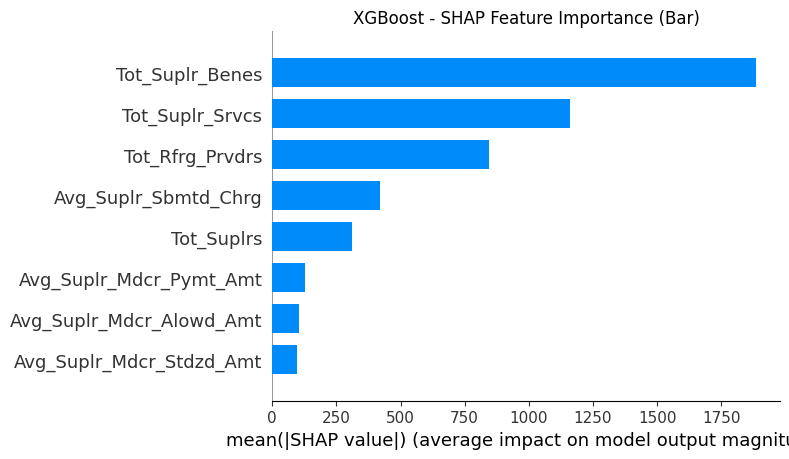

In [138]:
#DataFrame
X_test_sample_df = pd.DataFrame(X_test_sample, columns=FEATURES)

#global feature importance plot
plt.title("XGBoost - SHAP Feature Importance (Bar)")
shap.summary_plot(shap_values_xgb, X_test_sample_df, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

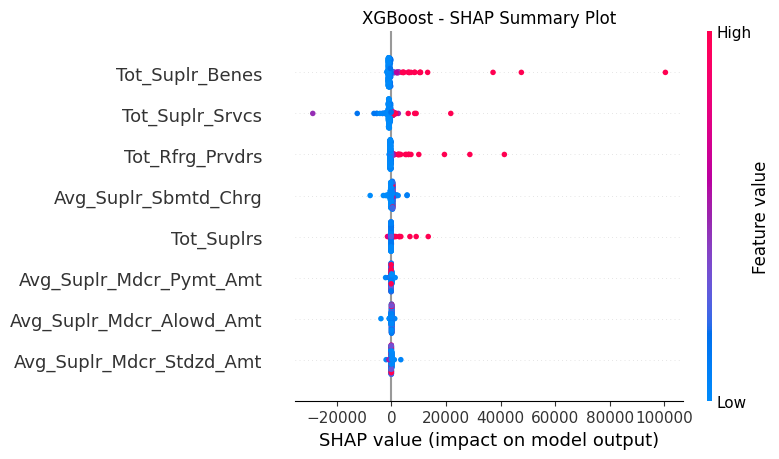

In [142]:
#Summary plot
plt.title("XGBoost - SHAP Summary Plot")
shap.summary_plot(shap_values_xgb, X_test_sample_df, show=False)
plt.tight_layout()
plt.show()

### N-BEATS (DEEP LEARNING MODEL)

In [101]:
print("EXTENDED N-BEATS (2014–2023)")
data_path_ext = os.path.join(EXT_OUTPUT_DIR, "dme_train_ready_2014_2023.csv")
df_ext = pd.read_csv(data_path_ext)
print(f"Loaded extended dataset for N-BEATS from: {data_path_ext}")
print("Shape:", df_ext.shape)

# Drop missing State rows
missing_states_ext = df_ext["State"].isna().sum()
print(f"Dropping {missing_states_ext} rows with missing 'State' (extended N-BEATS)")
df_ext = df_ext.dropna(subset=["State"]).reset_index(drop=True)
print("After drop:", df_ext.shape)

EXTENDED N-BEATS (2014–2023)
Loaded extended dataset for N-BEATS from: ./processed_2014_2023\dme_train_ready_2014_2023.csv
Shape: (374948, 12)
Dropping 0 rows with missing 'State' (extended N-BEATS)
After drop: (374948, 12)


In [102]:
#Target and Features
TARGET = "Tot_Suplr_Clms"
FEATURES = [
    "Tot_Rfrg_Prvdrs",
    "Tot_Suplrs",
    "Tot_Suplr_Benes",
    "Tot_Suplr_Srvcs",
    "Avg_Suplr_Sbmtd_Chrg",
    "Avg_Suplr_Mdcr_Alowd_Amt",
    "Avg_Suplr_Mdcr_Pymt_Amt",
    "Avg_Suplr_Mdcr_Stdzd_Amt"
]
df_ext = df_ext.sort_values(["State", "HCPCS_Cd", "Year"]).reset_index(drop=True)
seq_length = 3 
print("Sequence length:", seq_length)
print("Number of features:", len(FEATURES))

Sequence length: 3
Number of features: 8


In [103]:
X_seq_list = []
y_seq_list = []
print("\nCreating sequences for extended N-BEATS")
group_cols = ["State", "HCPCS_Cd"]

for (state, code), group in df_ext.groupby(group_cols):
    group = group.reset_index(drop=True)
    X_vals = group[FEATURES].values
    y_vals = group[TARGET].values.reshape(-1, 1)
    if len(group) <= seq_length:
        continue
    for i in range(len(group) - seq_length):
        X_seq_list.append(X_vals[i:i+seq_length])
        y_seq_list.append(y_vals[i+seq_length])

X_seq = np.array(X_seq_list)
y_seq = np.array(y_seq_list)

print("\nSequential dataset prepared (extended).")
print(f"Features (X_seq) shape: {X_seq.shape}")
print(f"Target   (y_seq) shape: {y_seq.shape}")


Creating sequences for extended N-BEATS

Sequential dataset prepared (extended).
Features (X_seq) shape: (238001, 3, 8)
Target   (y_seq) shape: (238001, 1)


In [104]:
# 80/20 split on sequences
split_ratio = 0.8
split_idx = int(len(X_seq) * split_ratio)

X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

# Scale features and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train.shape)

X_test_scaled = scaler_X.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print("Data scaling complete for extended N-BEATS.")
print("Train shape:", X_train_scaled.shape, y_train_scaled.shape)
print("Test shape :", X_test_scaled.shape, y_test_scaled.shape)

Data scaling complete for extended N-BEATS.
Train shape: (190400, 3, 8) (190400, 1)
Test shape : (47601, 3, 8) (47601, 1)


In [105]:
class DMEDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
batch_size = 64
train_loader = DataLoader(
    DMEDataset(X_train_scaled, y_train_scaled),
    batch_size=batch_size,
    shuffle=True
)
test_loader = DataLoader(
    DMEDataset(X_test_scaled, y_test_scaled),
    batch_size=batch_size,
    shuffle=False
)
print(f"DataLoaders ready (extended): {len(train_loader)} train batches, {len(test_loader)} test batches.")

DataLoaders ready (extended): 2975 train batches, 744 test batches.


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

input_size = X_train_scaled.shape[1] * X_train_scaled.shape[2]  # seq_len * num_features

class NBeatsBlock(nn.Module):
    def __init__(self, input_size, hidden_size, theta_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, hidden_size)
        self.theta_layer = nn.Linear(hidden_size, theta_size)
        self.backcast_size = input_size
        self.forecast_size = 1

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        theta = self.theta_layer(x)
        backcast = theta[:, :self.backcast_size]
        forecast = theta[:, -self.forecast_size:]
        return backcast, forecast

class NBeats(nn.Module):
    def __init__(self, input_size, hidden_size=128, n_blocks=3):
        super().__init__()
        self.blocks = nn.ModuleList([
            NBeatsBlock(input_size, hidden_size, input_size + 1)
            for _ in range(n_blocks)
        ])

    def forward(self, x):
        residual = x.view(x.size(0), -1)
        forecast = torch.zeros(residual.size(0), 1, device=x.device)
        for block in self.blocks:
            backcast, block_forecast = block(x)
            residual = residual - backcast
            forecast = forecast + block_forecast
        return forecast

model_nbeats_ext = NBeats(input_size=input_size).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_nbeats_ext.parameters(), lr=1e-3)

epochs = 30
print("\nStarting extended N-BEATS training")
for epoch in range(1, epochs + 1):
    model_nbeats_ext.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model_nbeats_ext(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch}/{epochs}] - Loss: {epoch_loss:.6f}")

print("Extended N-BEATS training complete!")

Using device: cpu

Starting extended N-BEATS training
Epoch [1/30] - Loss: 0.212733
Epoch [2/30] - Loss: 0.112064
Epoch [3/30] - Loss: 0.087075
Epoch [4/30] - Loss: 0.094529
Epoch [5/30] - Loss: 0.072660
Epoch [6/30] - Loss: 0.064074
Epoch [7/30] - Loss: 0.067779
Epoch [8/30] - Loss: 0.061003
Epoch [9/30] - Loss: 0.051464
Epoch [10/30] - Loss: 0.047525
Epoch [11/30] - Loss: 0.049044
Epoch [12/30] - Loss: 0.044373
Epoch [13/30] - Loss: 0.044754
Epoch [14/30] - Loss: 0.041089
Epoch [15/30] - Loss: 0.038769
Epoch [16/30] - Loss: 0.038930
Epoch [17/30] - Loss: 0.041282
Epoch [18/30] - Loss: 0.042809
Epoch [19/30] - Loss: 0.038588
Epoch [20/30] - Loss: 0.038677
Epoch [21/30] - Loss: 0.027592
Epoch [22/30] - Loss: 0.034310
Epoch [23/30] - Loss: 0.031222
Epoch [24/30] - Loss: 0.031613
Epoch [25/30] - Loss: 0.036969
Epoch [26/30] - Loss: 0.028634
Epoch [27/30] - Loss: 0.028811
Epoch [28/30] - Loss: 0.026346
Epoch [29/30] - Loss: 0.030174
Epoch [30/30] - Loss: 0.028494
Extended N-BEATS training

In [107]:
# Evaluation
model_nbeats_ext.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model_nbeats_ext(X_batch)
        y_pred.append(preds.cpu().numpy())
        y_true.append(y_batch.numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

# Inverse scaling
y_true_real = scaler_y.inverse_transform(y_true)
y_pred_real = scaler_y.inverse_transform(y_pred)

# Metrics
mae_ext = mean_absolute_error(y_true_real, y_pred_real)
rmse_ext = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
r2_ext = r2_score(y_true_real, y_pred_real)

print("\nExtended N-BEATS Evaluation (2014–2023 dataset):")
print(f"R² Score: {r2_ext:.4f}")
print(f"MAE     : {mae_ext:,.2f}")
print(f"RMSE    : {rmse_ext:,.2f}")


Extended N-BEATS Evaluation (2014–2023 dataset):
R² Score: 0.9777
MAE     : 496.48
RMSE    : 2,040.03


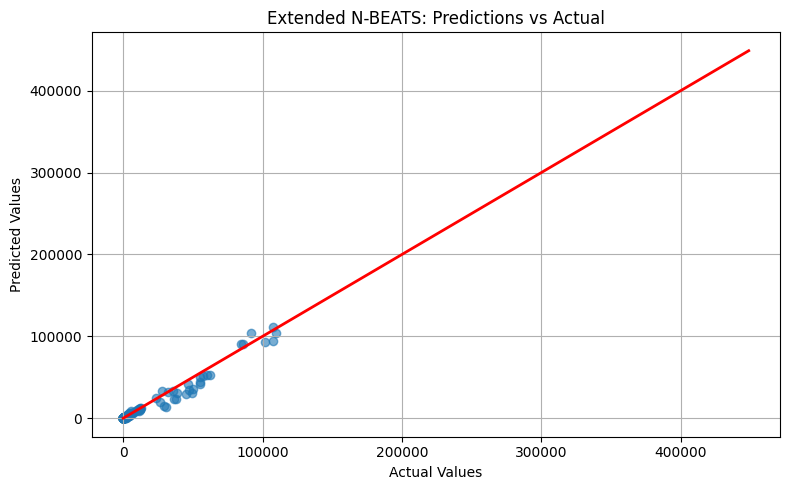

In [111]:
# Actual vs Predicted plot for extended N-BEATS
plt.figure(figsize=(8, 5))
plt.scatter(y_true_real[:200], y_pred_real[:200], alpha=0.6)
plt.plot(
    [y_true_real.min(), y_true_real.max()],
    [y_true_real.min(), y_true_real.max()],
    color='red',
    lw=2
)
plt.title("Extended N-BEATS: Predictions vs Actual")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid(True)
plt.tight_layout()
plt.show()

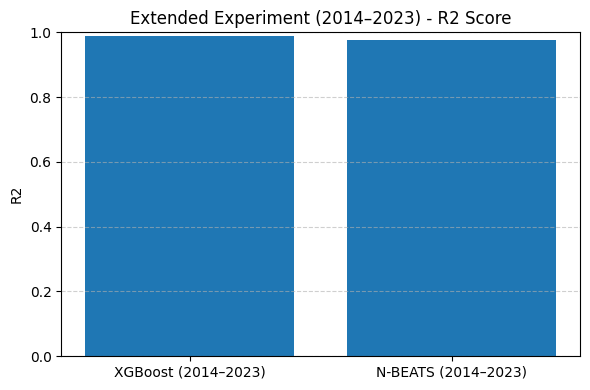

In [141]:
#Variance Plot
plt.figure(figsize=(6, 4))
plt.bar(df_results_ext["Model"], df_results_ext["R2"])
plt.title("Extended Experiment (2014–2023) - R2 Score")
plt.ylabel("R2")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

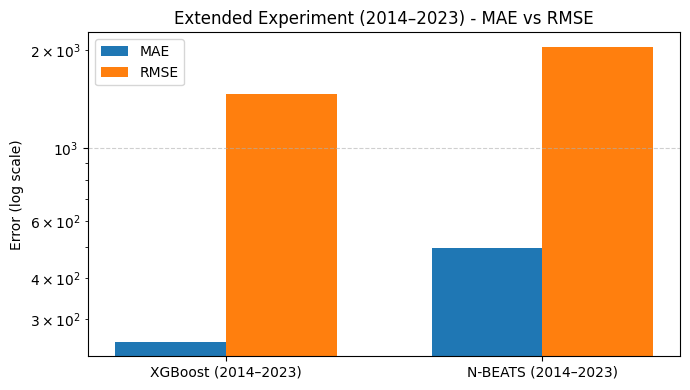

In [121]:
#Error Metrics Plot
plt.figure(figsize=(7, 4))
x = np.arange(len(df_results_ext["Model"]))
width = 0.35

plt.bar(x - width/2, df_results_ext["MAE"], width, label="MAE")
plt.bar(x + width/2, df_results_ext["RMSE"], width, label="RMSE")

plt.xticks(x, df_results_ext["Model"], rotation=0)
plt.yscale("log")
plt.ylabel("Error (log scale)")
plt.title("Extended Experiment (2014–2023) - MAE vs RMSE")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### MODEL COMPARISON

In [145]:
#Model comparison
results_ext = [
    {
        "Model": "XGBoost (2014–2023)",
        "RMSE": xgb_rmse_ext,
        "MAE": xgb_mae_ext,
        "R2": xgb_r2_ext
    }
]
results_ext.append({
    "Model": "N-BEATS (2014–2023)",
    "RMSE": round(rmse_ext, 2),
    "MAE": round(mae_ext, 2),
    "R2": round(r2_ext, 4)
})
df_results_ext = pd.DataFrame(results_ext)
print("\nExtended model comparison:\n")
print(df_results_ext)


Extended model comparison:

                 Model         RMSE         MAE      R2
0  XGBoost (2014–2023)  1461.680000  256.330000  0.9883
1  N-BEATS (2014–2023)  2040.030029  496.480011  0.9777


In [144]:
# Previous results comparison
xgb_r2_old = 0.9812
xgb_mae_old = 211.84
xgb_rmse_old = 1755.28
nbeats_r2_old = 0.9801
nbeats_mae_old = 517.92
nbeats_rmse_old = 1953.51
comparison = {
    "Model": ["XGBoost", "N-BEATS"],
    "R2 (2014–2022)": [xgb_r2_old, nbeats_r2_old],
    "R2 (2014–2023)": [round(xgb_r2_ext, 4), round(nbeats_r2_ext, 4)],
    "MAE (2014–2022)": [xgb_mae_old, nbeats_mae_old],
    "MAE (2014–2023)": [round(xgb_mae_ext, 2), round(nbeats_mae_ext, 2)],
    "RMSE (2014–2022)": [xgb_rmse_old, nbeats_rmse_old],
    "RMSE (2014–2023)": [round(xgb_rmse_ext, 2), round(nbeats_rmse_ext, 2)]
}
df_compare = pd.DataFrame(comparison)
print("\nXGBoost vs N-BEATS - OLD vs EXTENDED RESULTS:")
print(df_compare)


XGBoost vs N-BEATS - OLD vs EXTENDED RESULTS:
     Model  R2 (2014–2022)  R2 (2014–2023)  MAE (2014–2022)  MAE (2014–2023)  \
0  XGBoost          0.9812          0.9883           211.84       256.330000   
1  N-BEATS          0.9801          0.9777           517.92       496.480011   

   RMSE (2014–2022)  RMSE (2014–2023)  
0           1755.28       1461.680000  
1           1953.51       2040.030029  


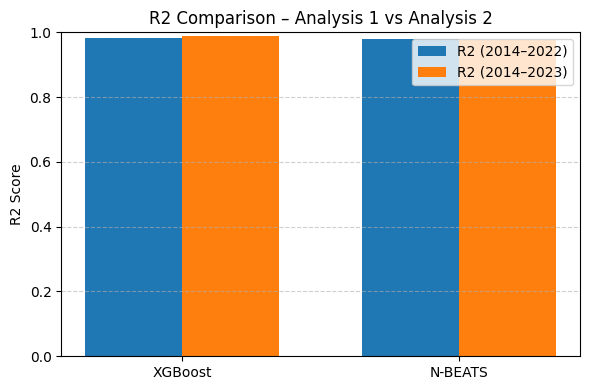

In [149]:
#Visualisation
# R2 comparison: 2014–2022 vs 2014–2023
models = df_compare["Model"].values
r2_old = df_compare["R2 (2014–2022)"].values
r2_new = df_compare["R2 (2014–2023)"].values
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, r2_old, width, label="R2 (2014–2022)")
plt.bar(x + width/2, r2_new, width, label="R2 (2014–2023)")
plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel("R2 Score")
plt.title("R2 Comparison – Analysis 1 vs Analysis 2")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()